# Course 4 Week 1: Foundations of Convolutional Neural Networks
## Complete Implementation and Exploration


## Part 1: Edge Detection and Basic Operations

In [7]:
%pip install numpy matplotlib tensorflow seaborn scipy opencv-python scikit-learn


  Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 7.8 MB/s  0:00:02m0:00:0100:01
Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl (37.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 8.0 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 9.1 MB/s  0:00:00 eta 0:00:01m
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:
      Successfully uninstalled numpy-2.3.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]]
Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns
from scipy.signal import convolve2d
import cv2
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


### Edge Detection Example
**Title:** Understanding Convolution Through Edge Detection

**Description:** 
Implements manual convolution to understand the mathematical foundation of CNNs. Demonstrates how convolution detects edges using a simple 6×6 image with a clear vertical boundary. Shows step-by-step calculations for the convolution operation.

**Key Formulas:**
- Convolution operation: $(I * K)[i,j] = \sum_{m} \sum_{n} I[i+m, j+n] \cdot K[m,n]$
- Output size: $\text{Output} = n - f + 1$
- Output height: $H_{out} = H_{in} - H_{k} + 1$
- Output width: $W_{out} = W_{in} - W_{k} + 1$


**Learning Objectives:**
- Understand convolution mathematics
- See how filters detect specific patterns
- Learn manual convolution implementation


#### Create a simple 6x6 image with clear vertical edge (bright left, dark right)

In [ ]:
def create_simple_image():
    image = np.array([
        [10, 10, 10,  0,  0,  0],
        [10, 10, 10,  0,  0,  0],
        [10, 10, 10,  0,  0,  0],
        [10, 10, 10,  0,  0,  0],
        [10, 10, 10,  0,  0,  0],
        [10, 10, 10,  0,  0,  0]
    ], dtype=np.float32)

    return image

#### Create a 3x3 vertical edge detection filter

In [13]:
def vertical_edge_filter():
    return np.array([
        [1, 0, 1],
        [1, 0, 1],
        [1, 0, 1]
    ], dtype=np.float32)

#### Create a 3x3 horizontal edge detection filter

In [14]:
def horizontal_edge_filter():
    return np.array([
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1]
    ], dtype=np.float32)


#### Perform convolution manually to understand the process

In [18]:
def manual_convolution(image, kernel):
    # get dimensions
    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # calculate output size
    output_h = img_h - kernel_h +1
    output_w = img_w - kernel_w + 1
    output = np.zeros((output_h, output_w))

    print(f"Input shape: {image.shape}")
    print(f"Kernel shape: {kernel.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Output size formula: ({img_h} - {kernel_h} + 1) × ({img_w} - {kernel_w} + 1) = {output_h} × {output_w}")
    
    # perform convolution
    for i in range(output_h):
        for j in range(output_w):
            # extract region
            region = image[i:i+kernel_h, j:j+kernel_w]
            # element wise multiplication and sum
            output[i, j] = np.sum(region * kernel)

            # show detailed calculation for first few position
            if i<2 and j<2:
                print(f"\nPosition ({i}, {j}):")
                print(f"Region:\n{region}")
                print(f"Kernel:\n{kernel}")
                print(f"Element-wise product sum: {output[i, j]}")

    return output

#### Test edge detection

In [19]:
simple_img = create_simple_image()
vert_filter = vertical_edge_filter()

print("\nOriginal Image (Bright left, Dark right):")
print(simple_img)

print("\nVertical Edge Filter:")
print(vert_filter)


Original Image (Bright left, Dark right):
[[10. 10. 10.  0.  0.  0.]
 [10. 10. 10.  0.  0.  0.]
 [10. 10. 10.  0.  0.  0.]
 [10. 10. 10.  0.  0.  0.]
 [10. 10. 10.  0.  0.  0.]
 [10. 10. 10.  0.  0.  0.]]

Vertical Edge Filter:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]


#### Perform manual convolution

In [20]:
result = manual_convolution(simple_img, vert_filter)

print(f"\nConvolution Result:")
print(result)

Input shape: (6, 6)
Kernel shape: (3, 3)
Output shape: (4, 4)
Output size formula: (6 - 3 + 1) × (6 - 3 + 1) = 4 × 4

Position (0, 0):
Region:
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 60.0

Position (0, 1):
Region:
[[10. 10.  0.]
 [10. 10.  0.]
 [10. 10.  0.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 30.0

Position (1, 0):
Region:
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 60.0

Position (1, 1):
Region:
[[10. 10.  0.]
 [10. 10.  0.]
 [10. 10.  0.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 30.0

Convolution Result:
[[60. 30. 30.  0.]
 [60. 30. 30.  0.]
 [60. 30. 30.  0.]
 [60. 30. 30.  0.]]


#### visualize

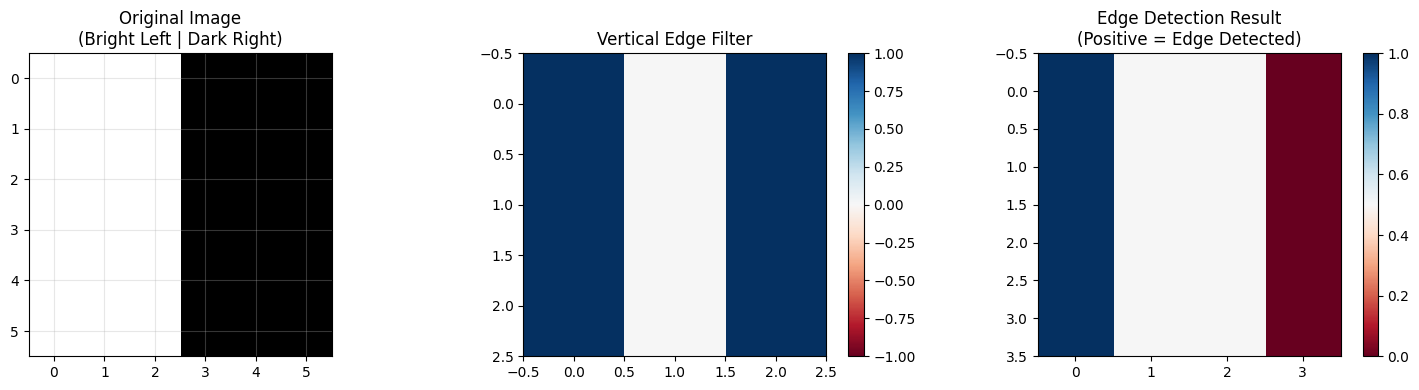

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(simple_img, cmap='gray', vmin=0, vmax=10)
axes[0].set_title('Original Image\n(Bright Left | Dark Right)')
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(vert_filter, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('Vertical Edge Filter')
plt.colorbar(im, ax=axes[1])

axes[2].imshow(result, cmap='RdBu')
axes[2].set_title('Edge Detection Result\n(Positive = Edge Detected)')
plt.colorbar(plt.cm.ScalarMappable(cmap='RdBu'), ax=axes[2])

plt.tight_layout()
plt.show()

### Cell 2: More Edge Detection - Different Directions and Filter Types
**Title:** Exploring Various Edge Detection Filters

**Description:**
Compares different edge detection filters including basic vertical/horizontal filters and improved Sobel filters. Demonstrates how different filters detect different types of patterns and edge orientations.

**Key Formulas:**
- Sobel vertical filter emphasizes center: $\begin{bmatrix} 1 & 0 & -1 \\ 2 & 0 & -2 \\ 1 & 0 & -1 \end{bmatrix}$
- Edge response indicates transition strength

**Learning Objectives:**
- Compare filter types and their effects
- Understand directional edge detection
- Learn about improved filters (Sobel, Scharr)


#### Sobel filter

In [23]:
def sobel_vertical():
    """Sobel vertical edge filter - weights center row more heavily"""
    return np.array([
        [ 1,  0, -1],
        [ 2,  0, -2],
        [ 1,  0, -1]
    ], dtype=np.float32)

def sobel_horizontal():
    """Sobel horizontal edge filter"""
    return np.array([
        [ 1,  2,  1],
        [ 0,  0,  0],
        [-1, -2, -1]
    ], dtype=np.float32)

#### Create a more complex image with both vertical and horizontal edges

In [25]:
def create_complex_image():
    """Create a more complex image with both vertical and horizontal edges"""
    image = np.array([
        [10, 10, 10,  0,  0,  0],
        [10, 10, 10,  0,  0,  0],
        [10, 10, 10,  0,  0,  0],
        [ 0,  0,  0, 10, 10, 10],
        [ 0,  0,  0, 10, 10, 10],
        [ 0,  0,  0, 10, 10, 10]
    ], dtype=np.float32)
    return image

complex_img = create_complex_image()

#### Test different filters

In [26]:
filters = {
    'Basic Vertical': vertical_edge_filter(),
    'Basic Horizontal': horizontal_edge_filter(),
    'Sobel Vertical': sobel_vertical(),
    'Sobel Horizontal': sobel_horizontal()
}

print("Complex Image (Checkerboard pattern):")
print(complex_img)

Complex Image (Checkerboard pattern):
[[10. 10. 10.  0.  0.  0.]
 [10. 10. 10.  0.  0.  0.]
 [10. 10. 10.  0.  0.  0.]
 [ 0.  0.  0. 10. 10. 10.]
 [ 0.  0.  0. 10. 10. 10.]
 [ 0.  0.  0. 10. 10. 10.]]


Input shape: (6, 6)
Kernel shape: (3, 3)
Output shape: (4, 4)
Output size formula: (6 - 3 + 1) × (6 - 3 + 1) = 4 × 4

Position (0, 0):
Region:
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 60.0

Position (0, 1):
Region:
[[10. 10.  0.]
 [10. 10.  0.]
 [10. 10.  0.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 30.0

Position (1, 0):
Region:
[[10. 10. 10.]
 [10. 10. 10.]
 [ 0.  0.  0.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 40.0

Position (1, 1):
Region:
[[10. 10.  0.]
 [10. 10.  0.]
 [ 0.  0. 10.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 30.0

Basic Vertical Filter:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Result:
[[60. 30. 30.  0.]
 [40. 30. 30. 20.]
 [20. 30. 30. 40.]
 [ 0. 30. 30. 60.]]
Input shape: (6, 6)
Kernel shape: (3, 3)
Output shape: (4, 4)
Output size formula: (6 - 3 + 1) × (6 - 3 + 1) = 4 × 4

Position (0, 0):
Region:
[[

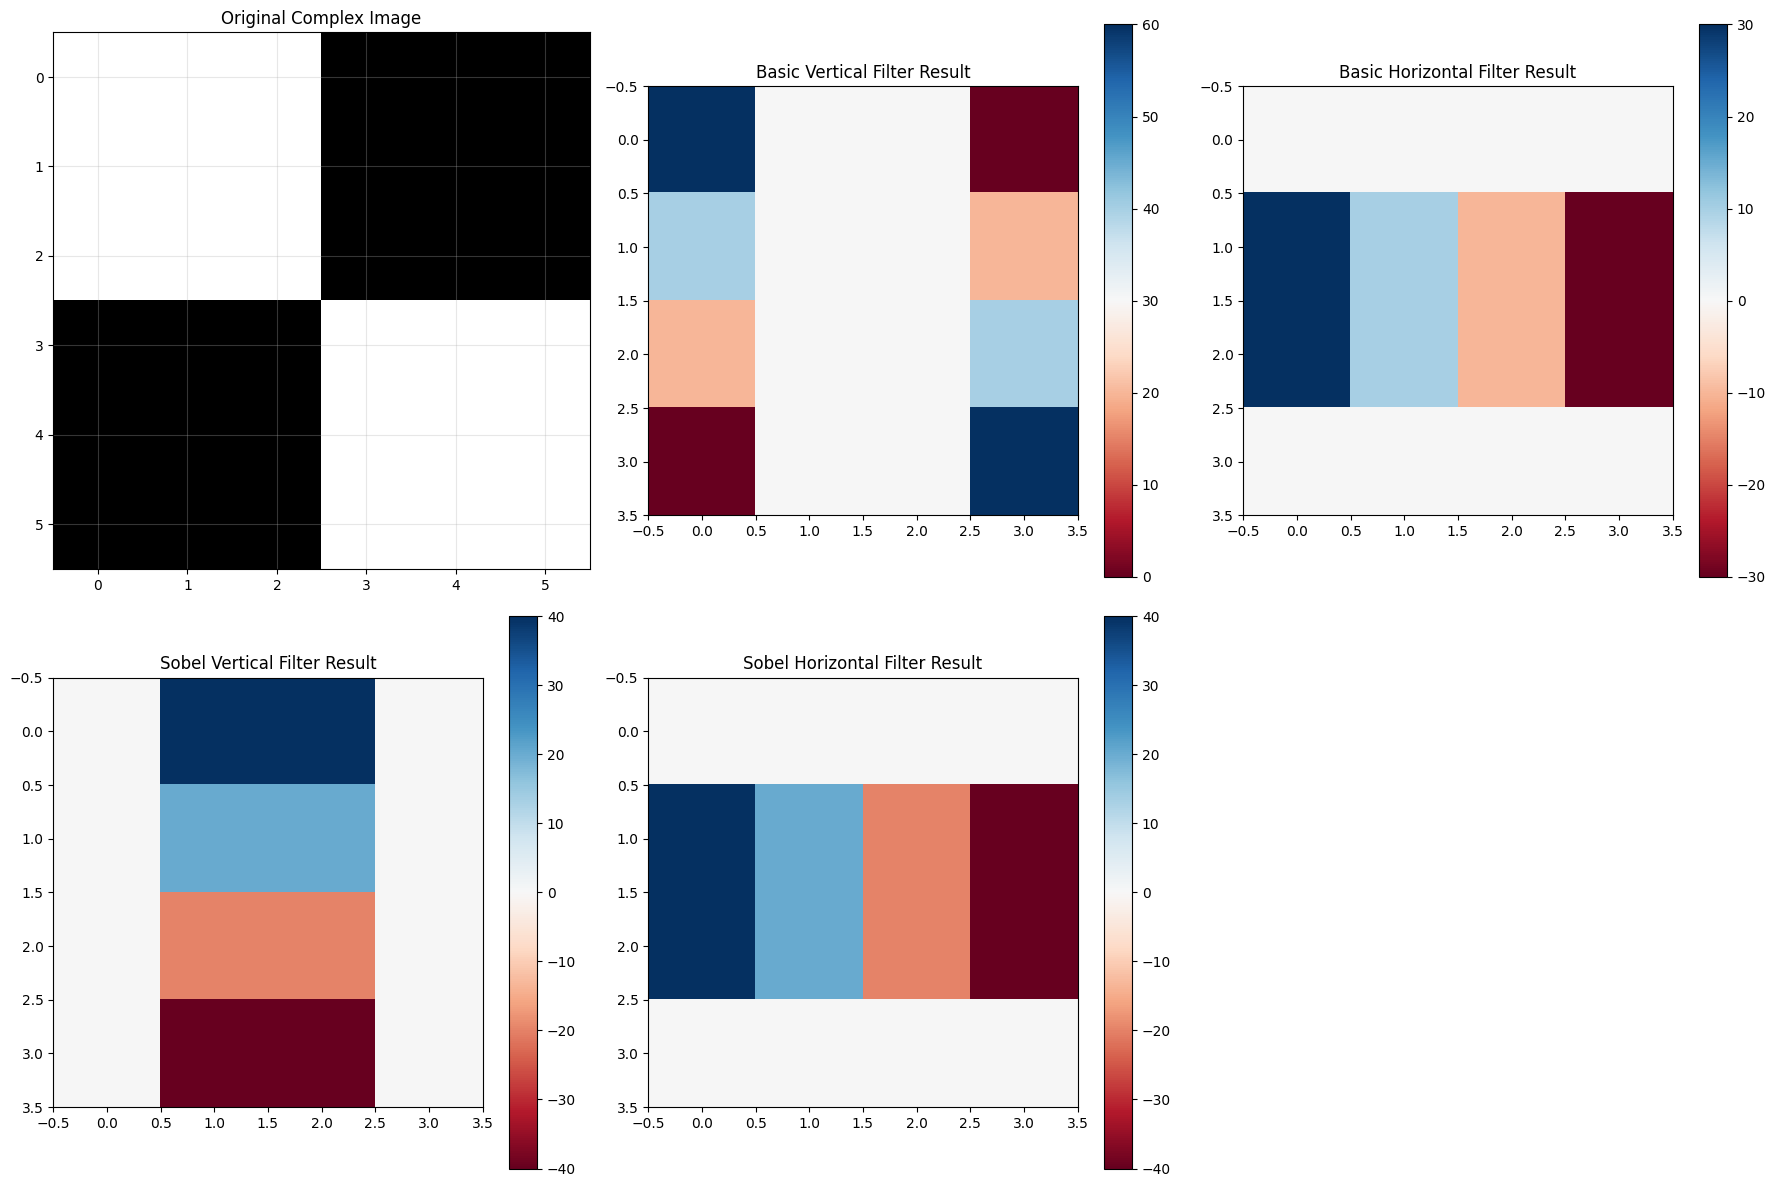

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(complex_img, cmap='gray')
axes[0, 0].set_title('Original Complex Image')
axes[0, 0].grid(True, alpha=0.3)

# Apply each filter
for idx, (name, filt) in enumerate(filters.items()):
    if idx < 5:  # We have 5 subplot positions
        row = (idx + 1) // 3
        col = (idx + 1) % 3
        
        result = manual_convolution(complex_img, filt)
        
        im = axes[row, col].imshow(result, cmap='RdBu')
        axes[row, col].set_title(f'{name} Filter Result')
        plt.colorbar(im, ax=axes[row, col])
        
        print(f"\n{name} Filter:")
        print(filt)
        print(f"Result:\n{result}")

# Hide the last subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


### Cell 3: Padding Implementation
**Title:** Understanding Padding: Solving Size Reduction and Edge Information Loss

**Description:**
Addresses two critical problems in CNNs: progressive image shrinkage and edge information loss. Demonstrates valid, same, and full padding strategies with mathematical calculations.

**Key Formulas:**
- With padding: $\text{Output} = n + 2p - f + 1$
- Same padding: $p = \frac{f-1}{2}$ (for odd filter sizes)
- Padding prevents shrinkage: maintain spatial dimensions

**Learning Objectives:**
- Understand why padding is necessary
- Calculate required padding for different scenarios
- Compare valid vs same padding strategies


#### Convolution Padding Types

##### Overview
Padding determines the output size after convolution. The general formula for output size is:

$$O = \frac{n + 2p - f}{s} + 1$$

Where:
- $n$ = input size
- $p$ = padding
- $f$ = filter size  
- $s$ = stride

##### 1. Valid Padding (No Padding)

**Padding:** $p = 0$

**Purpose:** Use only "valid" positions where the filter fits completely within the input.

**Example:** Input $6 \times 6$, Filter $3 \times 3$

$$
\text{Output size} = \frac{6 + 2(0) - 3}{1} + 1 = 4
$$

**Result:** $4 \times 4$ output

**Characteristics:**
- Output is smaller than input
- No zero-padding added
- Information at edges is lost

---

##### 2. Same Padding

**Padding:** $p = \frac{f-1}{2}$ (for odd filter sizes)

**Purpose:** Keep output size the same as input size.

**Example:** Input $6 \times 6$, Filter $3 \times 3$

Padding needed: $p = \frac{3-1}{2} = 1$

$$
\text{Output size} = \frac{6 + 2(1) - 3}{1} + 1 = 6
$$

**Input with padding:**
$$
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 10 & 10 & 10 & 0 & 0 & 0 & 0 \\
0 & 10 & 10 & 10 & 0 & 0 & 0 & 0 \\
0 & 10 & 10 & 10 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0
\end{bmatrix}
$$

**Result:** $6 \times 6$ output (same as input)

**Characteristics:**
- Output size = Input size
- Preserves spatial dimensions
- Most common in deep networks

---

##### 3. Full Padding

**Padding:** $p = f - 1$

**Purpose:** Ensure every input pixel is visited by every filter position at least once.

**Example:** Input $6 \times 6$, Filter $3 \times 3$

Padding needed: $p = 3 - 1 = 2$

$$
\text{Output size} = \frac{6 + 2(2) - 3}{1} + 1 = 8
$$

**Result:** $8 \times 8$ output

**Characteristics:**
- Output is larger than input
- Maximum information preservation
- Every input pixel contributes to multiple outputs
- Less common in practice

---

##### Quick Comparison

| Padding Type | Formula | Input: $6 \times 6$, Filter: $3 \times 3$ | Output Size |
|--------------|---------|-------------------------------------------|-------------|
| **Valid** | $p = 0$ | $\frac{6 + 0 - 3}{1} + 1 = 4$ | $4 \times 4$ |
| **Same** | $p = \frac{f-1}{2}$ | $\frac{6 + 2 - 3}{1} + 1 = 6$ | $6 \times 6$ |
| **Full** | $p = f-1$ | $\frac{6 + 4 - 3}{1} + 1 = 8$ | $8 \times 8$ |

###### Key Takeaway

- **Valid**: Output shrinks - loses edge information
- **Same**: Output stays same size - balanced approach  
- **Full**: Output grows - maximum information retention

#### `add_padding` Function

**Inputs:**
- `image`: A NumPy array (e.g., grayscale image as 2D, or could be extended to 3D with channels).  
- `pad_width`: How much padding to add around the image.  
  - Can be an integer (same padding on all sides), or a tuple like `((top, bottom), (left, right))`.  
- `mode`: Type of padding (default = `"constant"`).  
  - `"constant"` → adds a fixed value (like zeros).  
  - `"edge"` → repeats edge values.  
  - `"reflect"` → mirrors values.  
  - Any mode supported by `np.pad`.  
- `constant_value`: What value to use if mode is `"constant"` (default = 0, so zero-padding).  

---

**Logic:**
- If the mode is `"constant"`, it calls `np.pad(..., constant_values=constant_value)` so you can control what gets padded (e.g., black borders if `0`, white if `255`).  
- Otherwise, it just calls `np.pad` with the given mode (like `"reflect"` or `"edge"`).  

---

**Output:**
- Returns a new NumPy array with the padding applied.  

---

**Mathematical Formula (with padding):**  
For an input of size $n \times n$, filter size $f$, and padding $p$:  

$$
O = n + 2p - f + 1
$$


In [29]:
def add_padding(image, pad_width, mode='constant', constant_value=0):
    if mode=='constant':
        return np.pad(image, pad_width, mode='constant', constant_values=constant_value)
    else:
        return np.pad(image, pad_width, mode=mode)

In [30]:
def calculate_output_size(input_size, filter_size, padding=0, stride=1):
    """Calculate output size after convolution"""
    return int((input_size + 2*padding - filter_size) / stride) + 1

=== PADDING DEMONSTRATION ===
Original image shape: (6, 6)
Filter size: 3x3

Valid (no padding):
  Padding: 0
  Padded shape: (6, 6)
  Output size: 4×4
  Formula: (6 + 2×0 - 3)/1 + 1 = 4
Input shape: (6, 6)
Kernel shape: (3, 3)
Output shape: (4, 4)
Output size formula: (6 - 3 + 1) × (6 - 3 + 1) = 4 × 4

Position (0, 0):
Region:
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 60.0

Position (0, 1):
Region:
[[10. 10.  0.]
 [10. 10.  0.]
 [10. 10.  0.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 30.0

Position (1, 0):
Region:
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 60.0

Position (1, 1):
Region:
[[10. 10.  0.]
 [10. 10.  0.]
 [10. 10.  0.]]
Kernel:
[[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]]
Element-wise product sum: 30.0

Same padding:
  Padding: 1
  Padded shape: (8, 8)
  Output size: 6×6
  Formula: (8 + 2×0 - 3)/1 + 1 = 6

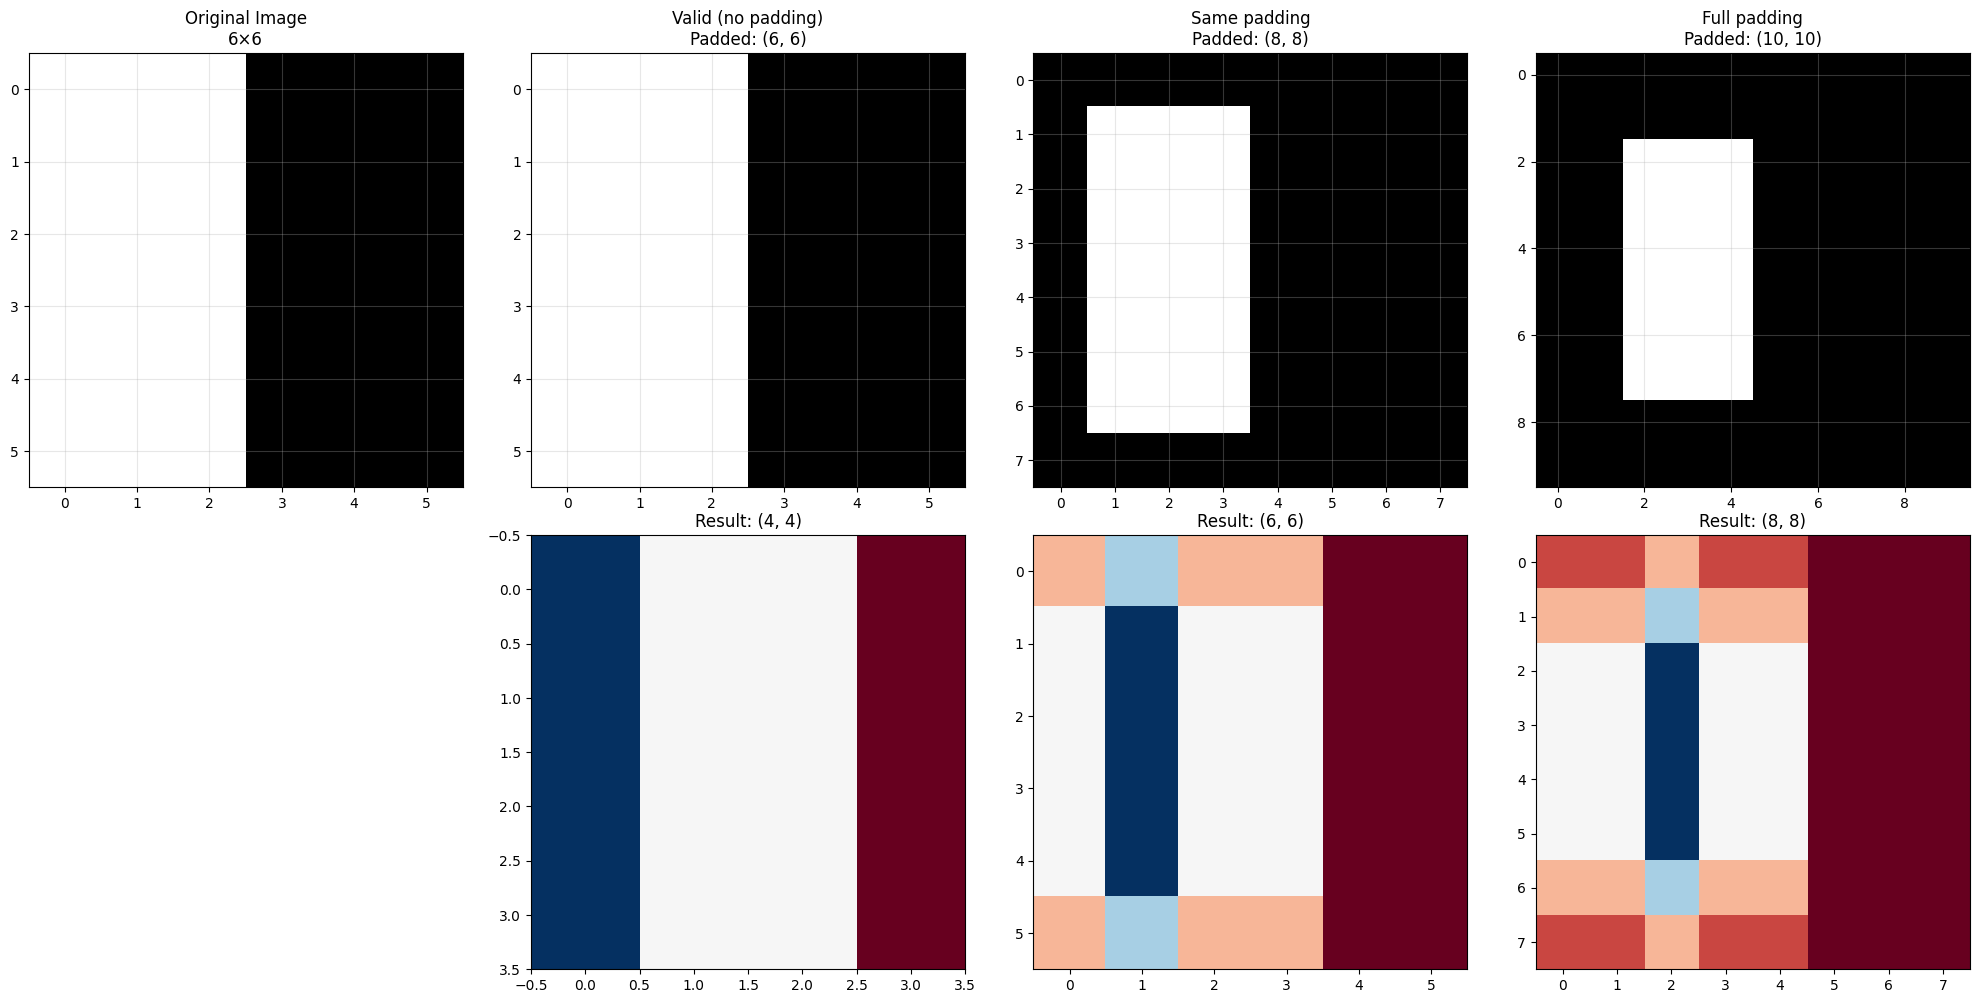

In [31]:
def demonstrate_padding_effect():
    """Demonstrate the effect of different padding strategies"""
    
    # Create a 6x6 image
    img = create_simple_image()
    filter_size = 3
    
    print("=== PADDING DEMONSTRATION ===")
    print(f"Original image shape: {img.shape}")
    print(f"Filter size: {filter_size}x{filter_size}")
    
    # Different padding strategies
    padding_strategies = {
        'Valid (no padding)': 0,
        'Same padding': (filter_size - 1) // 2,
        'Full padding': filter_size - 1
    }
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Original image
    axes[0, 0].imshow(img, cmap='gray')
    axes[0, 0].set_title('Original Image\n6×6')
    axes[0, 0].grid(True, alpha=0.3)
    
    for idx, (strategy, padding) in enumerate(padding_strategies.items()):
        # Add padding
        if padding > 0:
            padded_img = add_padding(img, padding)
        else:
            padded_img = img
            
        # Calculate output size
        output_size = calculate_output_size(padded_img.shape[0], filter_size, 0, 1)
        
        print(f"\n{strategy}:")
        print(f"  Padding: {padding}")
        print(f"  Padded shape: {padded_img.shape}")
        print(f"  Output size: {output_size}×{output_size}")
        print(f"  Formula: ({padded_img.shape[0]} + 2×0 - {filter_size})/1 + 1 = {output_size}")
        
        # Show padded image
        row = 0
        col = idx + 1
        axes[row, col].imshow(padded_img, cmap='gray')
        axes[row, col].set_title(f'{strategy}\nPadded: {padded_img.shape}')
        axes[row, col].grid(True, alpha=0.3)
        
        # Apply convolution and show result
        if idx < 3:  # We have space for 3 results
            result = manual_convolution(padded_img, vertical_edge_filter())
            row = 1
            axes[row, col].imshow(result, cmap='RdBu')
            axes[row, col].set_title(f'Result: {result.shape}')
    
    # Hide unused subplot
    axes[1, 0].axis('off')
    
    plt.tight_layout()
    plt.show()

demonstrate_padding_effect()

The visualization is showing **two different things**:

1. **Top row**: The **padded input images** (what goes INTO the convolution)
2. **Bottom row**: The **output results** (what comes OUT of the convolution)

Let me break down what's happening:

##### Valid Padding (Column 2)
- **Top image**: Shows padded input size `(6, 6)` - this is the same as original because no padding is added
- **Bottom image**: Shows the **result** size `(4, 4)` - this is the output after convolution
- Your output correctly shows: `Padded shape: (6, 6)` and `Output size: 4×4`

##### Same Padding (Column 3)  
- **Top image**: Shows padded input size `(8, 8)` - original `(6, 6)` + padding of 1 on all sides = `(6+2, 6+2) = (8, 8)`
- **Bottom image**: Shows the **result** size `(6, 6)` - this matches the original input size (that's the goal of "same" padding)
- Your output correctly shows: `Padded shape: (8, 8)` and `Output size: 6×6`

##### The Key Point

The image titles are showing:
- **"Padded: (6, 6)"** for Valid → This means the input after padding (no padding added, so still 6×6)
- **"Padded: (8, 8)"** for Same → This means the input after padding (1 pixel border added, so 8×8)

But the **"Result:"** labels at the bottom show the actual convolution output sizes:
- Valid: Result (4, 4) 
- Same: Result (6, 6)
- Full: Result (8, 8)

### Cell 4: Strided Convolutions
**Title:** Understanding Stride: Controlling Filter Movement

**Description:**
Explores how stride controls filter movement and output size. Demonstrates the downsampling effect of different stride values and shows practical applications.

**Key Formulas:**
- Strided output size: $\text{Output} = \left\lfloor \frac{n + 2p - f}{s} \right\rfloor + 1$
- Stride 2 achieves 50% spatial reduction
- Floor function handles non-integer divisions

**Learning Objectives:**
- Control spatial downsampling with stride
- Understand computational efficiency gains
- Learn when to use different stride values

---


Stride controls how far the filter moves between applications.

1. Stride 1: Dense sampling, larger output
2. Stride 2: Skip positions, smaller output (50% reduction)
3. Stride > 2: Aggressive downsampling

In [34]:
def strided_convolution(image, kernel, stride=1, padding=0):
    """Perform convolution with specified stride"""
    
    # Add padding if specified
    if padding > 0:
        image = add_padding(image, padding)
    
    img_h, img_w = image.shape
    kernel_h, kernel_w = kernel.shape
    
    # Calculate output size with stride
    output_h = int((img_h - kernel_h) / stride) + 1
    output_w = int((img_w - kernel_w) / stride) + 1
    output = np.zeros((output_h, output_w))
    
    print(f"Input shape: {image.shape}")
    print(f"Kernel shape: {kernel.shape}")
    print(f"Stride: {stride}")
    print(f"Output shape: {output.shape}")
    print(f"Formula: ⌊({img_h} - {kernel_h})/{stride}⌋ + 1 = {output_h}")
    
    # Perform strided convolution
    for i in range(output_h):
        for j in range(output_w):
            # Calculate input position based on stride
            start_i = i * stride
            start_j = j * stride
            end_i = start_i + kernel_h
            end_j = start_j + kernel_w
            
            # Extract region and apply kernel
            region = image[start_i:end_i, start_j:end_j]
            output[i, j] = np.sum(region * kernel)
            
            # Show first few calculations
            if i < 2 and j < 2:
                print(f"\nPosition ({i},{j}) -> Input region ({start_i}:{end_i}, {start_j}:{end_j})")
                print(f"Region:\n{region}")
                print(f"Result: {output[i, j]}")
    
    return output

##### Create 7x7 image to match video example

In [35]:

large_img = np.random.randint(0, 10, (7, 7)).astype(np.float32)
print("7×7 Input Image:")
print(large_img)

7×7 Input Image:
[[6. 6. 7. 0. 4. 9. 7.]
 [8. 0. 5. 6. 4. 0. 0.]
 [2. 3. 4. 7. 1. 5. 4.]
 [1. 3. 1. 8. 9. 1. 0.]
 [3. 9. 6. 9. 4. 3. 6.]
 [6. 6. 6. 5. 8. 4. 9.]
 [9. 7. 4. 0. 2. 6. 9.]]


##### Test different strides


--- STRIDE 1 ---
Input shape: (7, 7)
Kernel shape: (3, 3)
Stride: 1
Output shape: (5, 5)
Formula: ⌊(7 - 3)/1⌋ + 1 = 5

Position (0,0) -> Input region (0:3, 0:3)
Region:
[[6. 6. 7.]
 [8. 0. 5.]
 [2. 3. 4.]]
Result: 32.0

Position (0,1) -> Input region (0:3, 1:4)
Region:
[[6. 7. 0.]
 [0. 5. 6.]
 [3. 4. 7.]]
Result: 22.0

Position (1,0) -> Input region (1:4, 0:3)
Region:
[[8. 0. 5.]
 [2. 3. 4.]
 [1. 3. 1.]]
Result: 21.0

Position (1,1) -> Input region (1:4, 1:4)
Region:
[[0. 5. 6.]
 [3. 4. 7.]
 [3. 1. 8.]]
Result: 27.0
Size reduction: 49.0%

--- STRIDE 2 ---
Input shape: (7, 7)
Kernel shape: (3, 3)
Stride: 2
Output shape: (3, 3)
Formula: ⌊(7 - 3)/2⌋ + 1 = 3

Position (0,0) -> Input region (0:3, 0:3)
Region:
[[6. 6. 7.]
 [8. 0. 5.]
 [2. 3. 4.]]
Result: 32.0

Position (0,1) -> Input region (0:3, 2:5)
Region:
[[7. 0. 4.]
 [5. 6. 4.]
 [4. 7. 1.]]
Result: 25.0

Position (1,0) -> Input region (2:5, 0:3)
Region:
[[2. 3. 4.]
 [1. 3. 1.]
 [3. 9. 6.]]
Result: 17.0

Position (1,1) -> Input region (

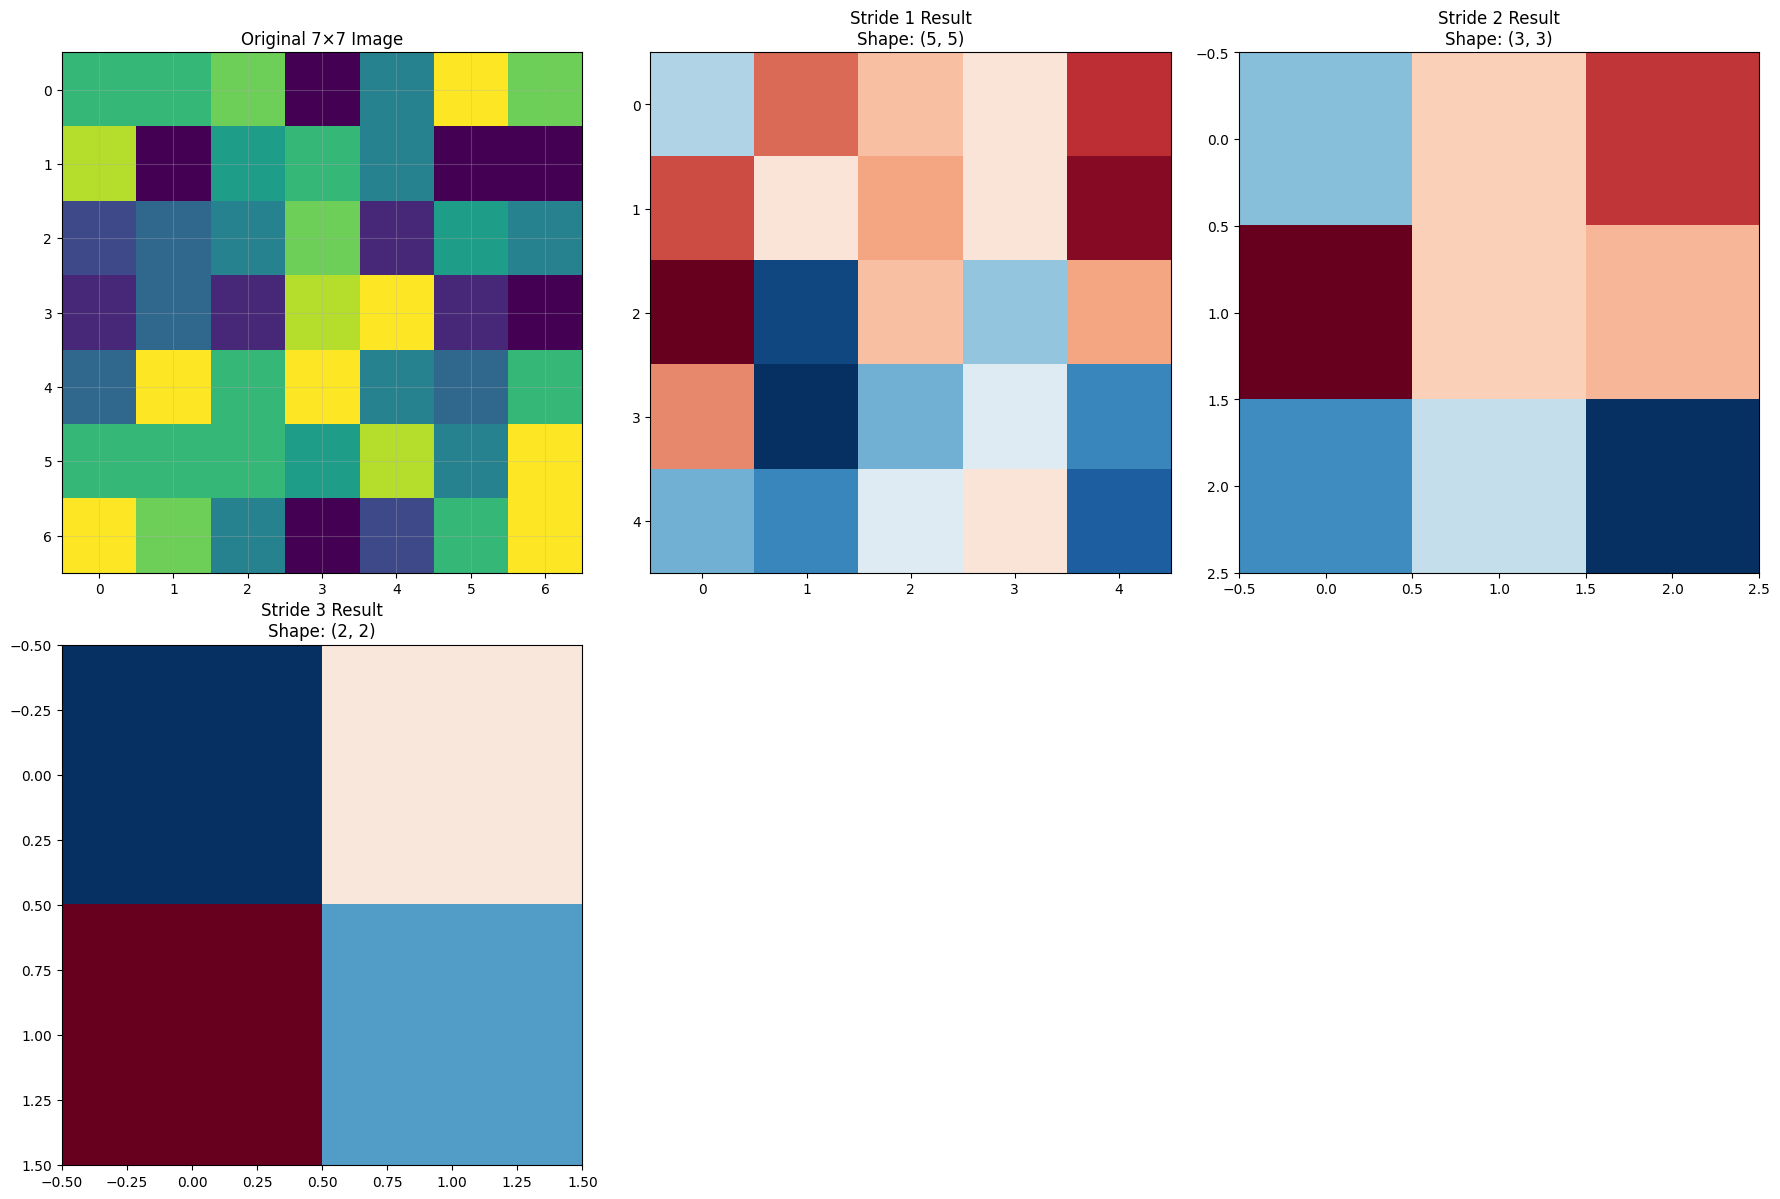

In [36]:
strides = [1, 2, 3]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(large_img, cmap='viridis')
axes[0, 0].set_title('Original 7×7 Image')
axes[0, 0].grid(True, alpha=0.3)

for idx, stride in enumerate(strides):
    print(f"\n--- STRIDE {stride} ---")
    result = strided_convolution(large_img, vertical_edge_filter(), stride=stride)
    
    # Plot result
    row = 0 if idx < 2 else 1
    col = (idx + 1) if idx < 2 else (idx - 2)
    
    axes[row, col].imshow(result, cmap='RdBu')
    axes[row, col].set_title(f'Stride {stride} Result\nShape: {result.shape}')
    
    # Show reduction percentage
    original_size = 7 * 7
    new_size = result.shape[0] * result.shape[1]
    reduction = (1 - new_size/original_size) * 100
    print(f"Size reduction: {reduction:.1f}%")

# Hide unused subplots
axes[1, 1].axis('off')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Cell 5: Convolutions Over Volume (3D)
**Title:** From 2D to 3D: Real-World RGB Image Processing

**Description:**
Extends convolution to 3D volumes for processing RGB images. Shows how filter depth must match input channels and demonstrates multiple filter applications.

**Key Formulas:**
- Filter constraint: $f_{depth} = n_{c_{input}}$
- 3D convolution: $\sum_{c=0}^{n_C-1} \sum_{u=0}^{f-1} \sum_{v=0}^{f-1} I[i+u, j+v, c] \times F[u, v, c]$
- Output channels = number of filters

**Learning Objectives:**
- Process RGB images with 3D convolution
- Understand filter depth requirements
- Learn multi-channel feature detection

---


In [47]:
def create_rgb_image(height=6, width=6):
    """Create a simple RGB image with distinct patterns per channel"""
    # Create patterns for each channel
    red_channel = np.array([
        [3, 0, 1, 2, 7, 4],
        [1, 5, 8, 9, 3, 1],
        [4, 2, 1, 6, 2, 8],
        [7, 3, 2, 1, 1, 3],
        [2, 4, 5, 2, 3, 1],
        [1, 0, 3, 4, 6, 2]
    ], dtype=np.float32)
    
    green_channel = np.array([
        [1, 5, 8, 9, 3, 1],
        [4, 2, 1, 6, 2, 8],
        [7, 3, 2, 1, 1, 3],
        [2, 4, 5, 2, 3, 1],
        [1, 0, 3, 4, 6, 2],
        [5, 2, 1, 3, 4, 7]
    ], dtype=np.float32)
    
    blue_channel = np.array([
        [2, 1, 2, 0, 1, 3],
        [0, 2, 2, 3, 4, 6],
        [1, 1, 3, 1, 7, 8],
        [3, 2, 4, 5, 1, 2],
        [4, 3, 1, 2, 5, 6],
        [2, 1, 0, 4, 3, 1]
    ], dtype=np.float32)
    
    # Stack channels
    rgb_image = np.stack([red_channel, green_channel, blue_channel], axis=-1)
    return rgb_image


In [48]:
def create_3d_filter(filter_type='vertical_edge'):
    """Create 3D filters for different types of edge detection"""
    if filter_type == 'vertical_edge':
        # Detect vertical edges across all channels
        filter_3d = np.array([
            [[ 1,  1,  1],  [ 0,  0,  0],  [-1, -1, -1]],
            [[ 1,  1,  1],  [ 0,  0,  0],  [-1, -1, -1]],
            [[ 1,  1,  1],  [ 0,  0,  0],  [-1, -1, -1]]
        ], dtype=np.float32)
        
    elif filter_type == 'red_edge':
        # Detect edges only in red channel
        filter_3d = np.array([
            [[ 1,  0,  0],  [ 0,  0,  0],  [-1,  0,  0]],
            [[ 1,  0,  0],  [ 0,  0,  0],  [-1,  0,  0]],
            [[ 1,  0,  0],  [ 0,  0,  0],  [-1,  0,  0]]
        ], dtype=np.float32)
        
    elif filter_type == 'horizontal_edge':
        # Detect horizontal edges across all channels
        filter_3d = np.array([
            [[ 1,  1,  1],  [ 1,  1,  1],  [ 1,  1,  1]],
            [[ 0,  0,  0],  [ 0,  0,  0],  [ 0,  0,  0]],
            [[-1, -1, -1],  [-1, -1, -1],  [-1, -1, -1]]
        ], dtype=np.float32)
    
    return filter_3d


In [49]:
def convolution_3d(image, kernel):
    """Perform 3D convolution manually"""
    img_h, img_w, img_c = image.shape
    kernel_h, kernel_w, kernel_c = kernel.shape
    
    # Check depth compatibility
    if img_c != kernel_c:
        raise ValueError(f"Filter depth ({kernel_c}) must match input depth ({img_c})")
    
    # Calculate output size
    output_h = img_h - kernel_h + 1
    output_w = img_w - kernel_w + 1
    output = np.zeros((output_h, output_w))
    
    print(f"3D Convolution:")
    print(f"Input shape: {image.shape}")
    print(f"Filter shape: {kernel.shape}")
    print(f"Output shape: {output.shape}")
    
    # Perform 3D convolution
    for i in range(output_h):
        for j in range(output_w):
            # Extract 3D region
            region = image[i:i+kernel_h, j:j+kernel_w, :]
            # Element-wise multiplication across all channels and sum
            output[i, j] = np.sum(region * kernel)
            
            # Show detailed calculation for position (0,0)
            if i == 0 and j == 0:
                print(f"\nDetailed calculation at position (0,0):")
                for c in range(img_c):
                    channel_result = np.sum(region[:,:,c] * kernel[:,:,c])
                    print(f"Channel {c} contribution: {channel_result:.2f}")
                print(f"Total sum: {output[i, j]:.2f}")
    
    return output


##### Create RGB image

In [50]:

rgb_img = create_rgb_image()
print(f"RGB Image shape: {rgb_img.shape}")


RGB Image shape: (6, 6, 3)


##### Visualize RGB channels


--- VERTICAL_EDGE FILTER ---
Filter shape: (3, 3, 3)
3D Convolution:
Input shape: (6, 6, 3)
Filter shape: (3, 3, 3)
Output shape: (4, 4)

Detailed calculation at position (0,0):
Channel 0 contribution: -2.00
Channel 1 contribution: 1.00
Channel 2 contribution: -4.00
Total sum: -5.00

--- RED_EDGE FILTER ---
Filter shape: (3, 3, 3)
3D Convolution:
Input shape: (6, 6, 3)
Filter shape: (3, 3, 3)
Output shape: (4, 4)

Detailed calculation at position (0,0):
Channel 0 contribution: -2.00
Channel 1 contribution: 0.00
Channel 2 contribution: 0.00
Total sum: -2.00

--- HORIZONTAL_EDGE FILTER ---
Filter shape: (3, 3, 3)
3D Convolution:
Input shape: (6, 6, 3)
Filter shape: (3, 3, 3)
Output shape: (4, 4)

Detailed calculation at position (0,0):
Channel 0 contribution: -3.00
Channel 1 contribution: 2.00
Channel 2 contribution: 0.00
Total sum: -1.00


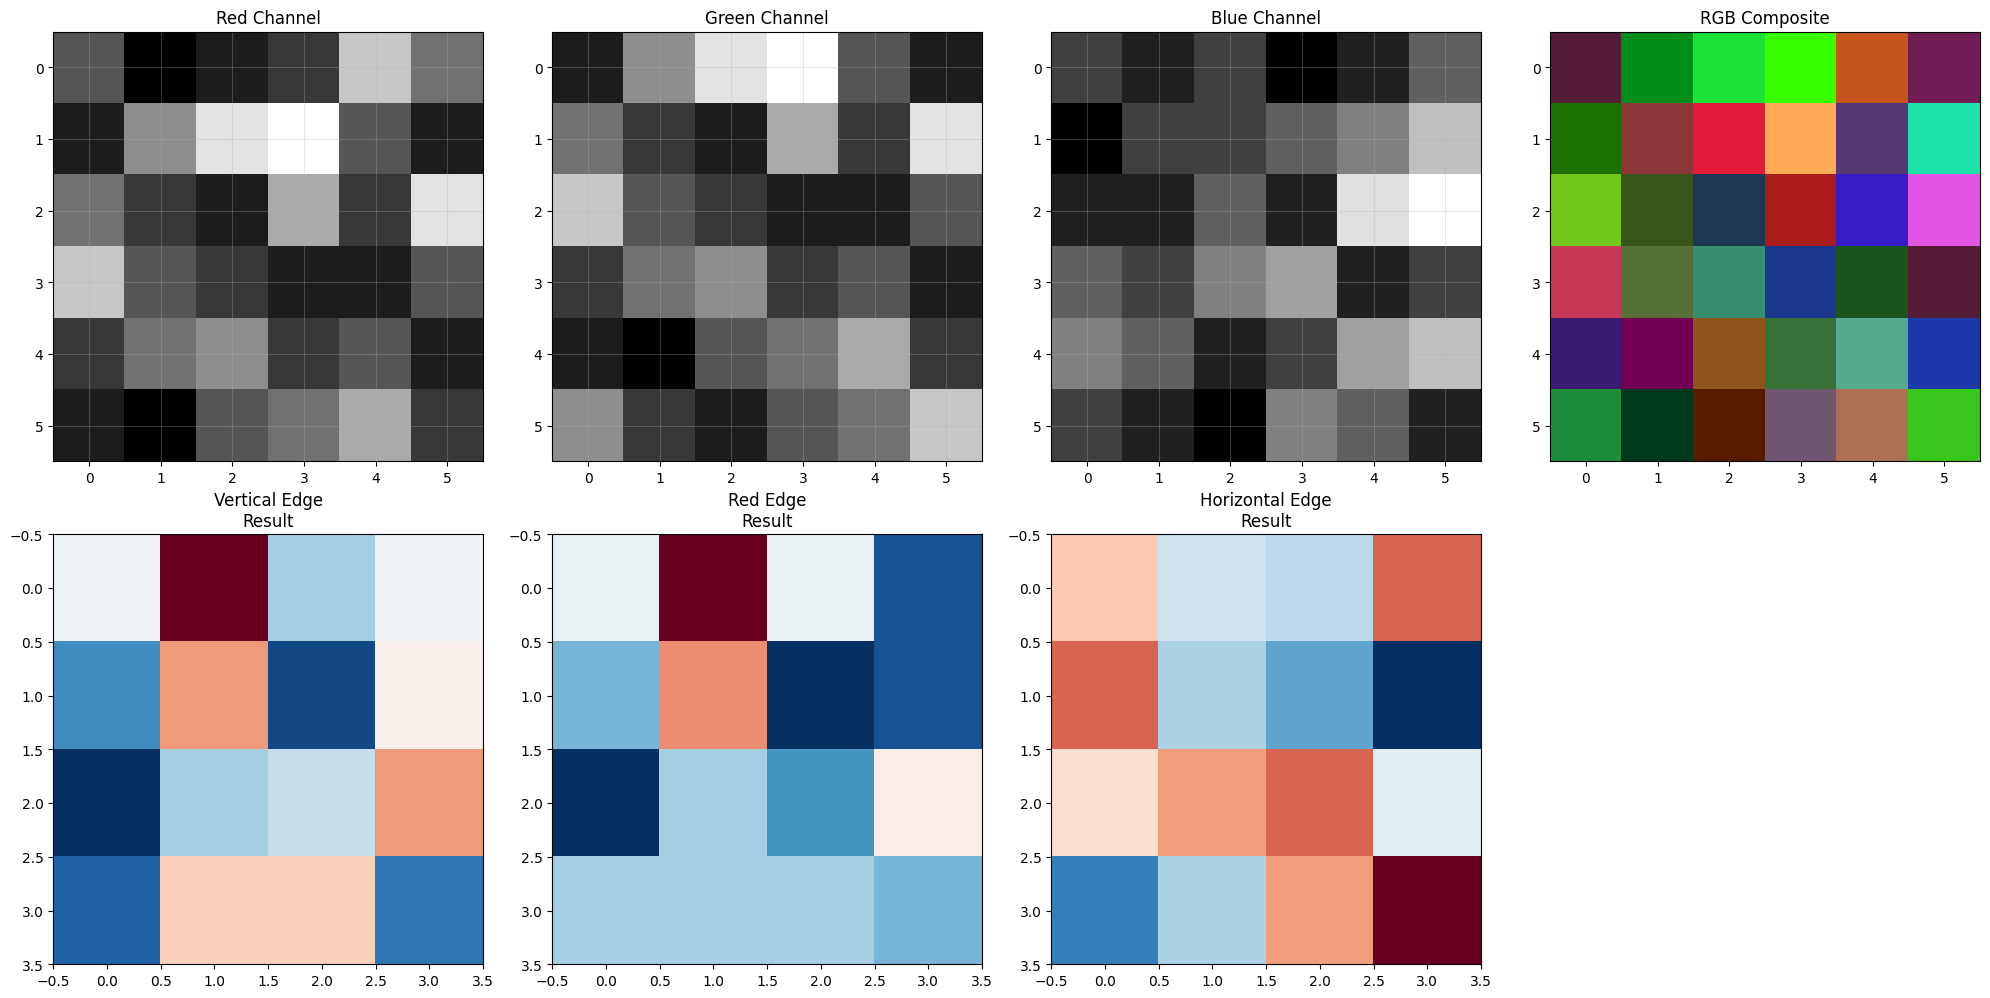

In [52]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Show individual channels
channel_names = ['Red', 'Green', 'Blue']
for i, (channel, name) in enumerate(zip([rgb_img[:,:,0], rgb_img[:,:,1], rgb_img[:,:,2]], channel_names)):
    axes[0, i].imshow(channel, cmap='gray')
    axes[0, i].set_title(f'{name} Channel')
    axes[0, i].grid(True, alpha=0.3)

# Show RGB composite
axes[0, 3].imshow(rgb_img / rgb_img.max())  # Normalize for display
axes[0, 3].set_title('RGB Composite')

# Test different 3D filters
filter_types = ['vertical_edge', 'red_edge', 'horizontal_edge']
for idx, filter_type in enumerate(filter_types):
    print(f"\n--- {filter_type.upper()} FILTER ---")
    filter_3d = create_3d_filter(filter_type)
    print(f"Filter shape: {filter_3d.shape}")
    
    result = convolution_3d(rgb_img, filter_3d)
    
    axes[1, idx].imshow(result, cmap='RdBu')
    axes[1, idx].set_title(f'{filter_type.replace("_", " ").title()}\nResult')

# Hide unused subplot
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

### Cell 6: One Layer of a Convolutional Network
**Title:** Building a Complete CNN Layer: Conv + Bias + Activation

**Description:**
Constructs a complete convolutional layer combining convolution, bias addition, and ReLU activation. Shows the full forward pass and parameter calculations.

**Key Formulas:**
- Complete layer: $a^{[l]} = g(W^{[l]} * a^{[l-1]} + b^{[l]})$
- ReLU activation: $g(z) = \max(0, z)$
- Parameters per layer: $(f \times f \times n_c^{[l-1]} + 1) \times n_c^{[l]}$

**Learning Objectives:**
- Build complete CNN layers
- Understand bias and activation roles
- Calculate layer parameters correctly

---


#### CNN Layer Forward Pass

##### Overview

A complete CNN layer performs three sequential operations:
1. **Convolution** with multiple filters
2. **Bias addition** for each filter
3. **Activation function** (typically ReLU)

The mathematical process can be expressed as:

$$\text{Output} = \text{ReLU}(\text{Convolution} + \text{Bias})$$

##### Multi-Filter Convolution Process

**Input Volume**: $(H \times W \times C)$ where:
- $H$ = height, $W$ = width, $C$ = channels

**Filters**: $N$ filters, each of size $(f \times f \times C)$ where:
- $f$ = filter size, $C$ = must match input channels
- $N$ = number of filters (determines output depth)

**Output Volume**: $(H' \times W' \times N)$ where:
- $H' = H - f + 1$ (for valid convolution)
- $W' = W - f + 1$
- $N$ = number of feature maps (one per filter)

##### Step-by-Step Forward Pass

##### Step 1: Convolution
For each filter $k$ and each spatial position $(i,j)$:

$$z_{i,j,k} = \sum_{u=0}^{f-1} \sum_{v=0}^{f-1} \sum_{c=0}^{C-1} x_{i+u,j+v,c} \cdot w_{u,v,c,k}$$

Where:
- $x$ = input volume
- $w$ = filter weights
- $z$ = convolution result

##### Step 2: Add Bias
$$z'_{i,j,k} = z_{i,j,k} + b_k$$

Where $b_k$ is the bias for filter $k$.

##### Step 3: Apply Activation
$$a_{i,j,k} = \text{ReLU}(z'_{i,j,k}) = \max(0, z'_{i,j,k})$$

##### Example Calculation

- **Input**: $6 \times 6 \times 3$ RGB image
- **Filters**: 2 filters of size $3 \times 3 \times 3$
- **Biases**: $[0.5, -0.2]$

##### Filter 1 at position (0,0):
- Convolution result: $-1.67$
- After bias: $-1.67 + 0.5 = -1.17$
- After ReLU: $\max(0, -1.17) = 0.00$

##### Filter 2 at position (0,0):
- Convolution result: $-0.33$
- After bias: $-0.33 + (-0.2) = -0.53$
- After ReLU: $\max(0, -0.53) = 0.00$

##### Output Characteristics

**Dimensions**: 
- Input: $(6, 6, 3)$
- Output: $(4, 4, 2)$

**Feature Maps**: Each filter produces one feature map:
- Filter 1 → Feature Map 1 (detects vertical edges)
- Filter 2 → Feature Map 2 (detects horizontal edges)

##### Key Properties

**Depth Expansion**: 
- Input depth: 3 (RGB channels)
- Output depth: 2 (number of filters)

**Spatial Reduction**: 
- Input spatial: $6 \times 6$
- Output spatial: $4 \times 4$ (due to valid convolution)

**Parameter Sharing**: 
- Each filter has the same weights across all spatial positions
- Total parameters per filter: $3 \times 3 \times 3 + 1 = 28$ (27 weights + 1 bias)

##### Mathematical Summary

For input volume $X \in \mathbb{R}^{H \times W \times C}$ and $N$ filters:

$$Y[:,:,k] = \text{ReLU}(\text{Conv}(X, W_k) + b_k)$$

Where:
- $Y \in \mathbb{R}^{H' \times W' \times N}$ is the output volume
- $W_k$ is the $k$-th filter
- $b_k$ is the $k$-th bias
- $\text{Conv}$ denotes the convolution operation

In [55]:
def relu_activation(x):
    """ReLU activation function: f(x) = max(0, x)"""
    return np.maximum(0, x)

In [ ]:
def conv_layer_forward(input_vol, filters, biases, activation_fn=relu_activation):
    """
    Forward pass through a complete convolutional layer
    
    Arguments:
    input_vol -- input volume (H, W, C)
    filters -- array of filters, each of shape (f, f, C)
    biases -- bias values for each filter
    activation_fn -- activation function to apply
    
    Returns:
    output_vol -- output volume after conv + bias + activation
    """
    
    input_h, input_w, input_c = input_vol.shape
    num_filters = len(filters)
    filter_h, filter_w, filter_c = filters[0].shape
    
    # Check filter depth compatibility
    if filter_c != input_c:
        raise ValueError(f"Filter depth ({filter_c}) must match input depth ({input_c})")
    
    # Calculate output dimensions
    output_h = input_h - filter_h + 1
    output_w = input_w - filter_w + 1
    output_vol = np.zeros((output_h, output_w, num_filters))
    
    print(f"CNN Layer Forward Pass:")
    print(f"Input volume: {input_vol.shape}")
    print(f"Number of filters: {num_filters}")
    print(f"Filter size: {filter_h}×{filter_w}×{filter_c}")
    print(f"Output volume: {output_vol.shape}")
    
    # Apply each filter
    for f_idx in range(num_filters):
        filter_kernel = filters[f_idx]
        bias = biases[f_idx]
        
        print(f"\nFilter {f_idx + 1}:" )
        print(f"Bias value: {bias}")
        
        # Convolve with current filter
        for i in range(output_h):
            for j in range(output_w):
                # Extract region
                region = input_vol[i:i+filter_h, j:j+filter_w, :]
                
                # Convolution: element-wise multiply and sum
                conv_result = np.sum(region * filter_kernel)
                
                # Add bias
                z = conv_result + bias
                
                # Apply activation
                a = activation_fn(z)
                
                # Store result
                output_vol[i, j, f_idx] = a
                
                # Show calculation for first position
                if i == 0 and j == 0:
                    print(f"  Position (0,0): conv={conv_result:.2f}, +bias={z:.2f}, after_relu={a:.2f}")
    
    return output_vol


CNN Layer Forward Pass:
Input volume: (6, 6, 3)
Number of filters: 2
Filter size: 3×3×3
Output volume: (4, 4, 2)

Filter 1: <class 'filter'>
Bias value: 0.5
  Position (0,0): conv=-1.67, +bias=-1.17, after_relu=0.00

Filter 2: <class 'filter'>
Bias value: -0.2
  Position (0,0): conv=-0.33, +bias=-0.53, after_relu=0.00


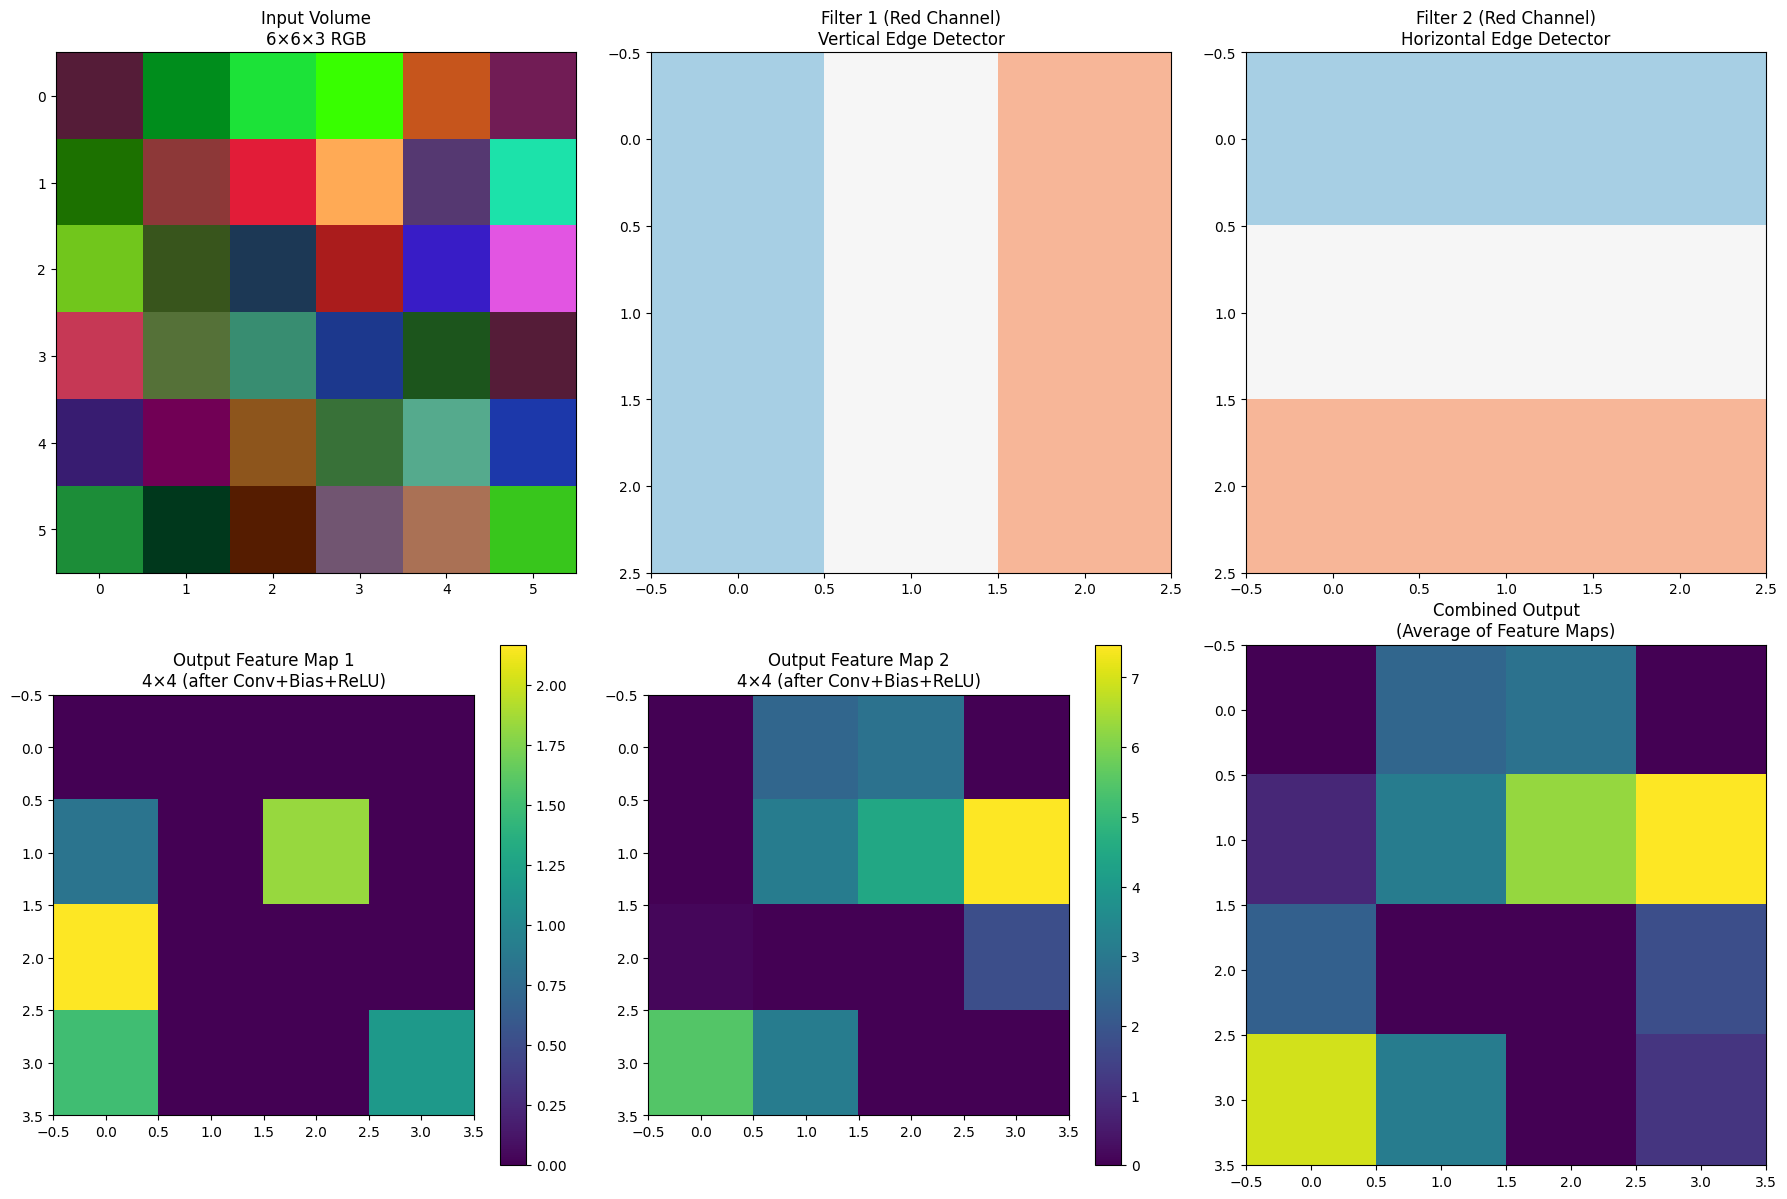

In [61]:
# Create input (6×6×3)
input_volume = create_rgb_image()

# Create multiple filters
filter1 = create_3d_filter('vertical_edge')  # Vertical edge detector
filter2 = create_3d_filter('horizontal_edge')  # Horizontal edge detector

# Normalize filters
filter1 = filter1 / 3.0  # Make values smaller for better demonstration
filter2 = filter2 / 3.0

filters = [filter1, filter2]
biases = [0.5, -0.2]  # Different bias for each filter

# Forward pass through CNN layer
output_volume = conv_layer_forward(input_volume, filters, biases)

# Visualize the complete process
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Input volume (RGB composite)
axes[0, 0].imshow(input_volume / input_volume.max())
axes[0, 0].set_title('Input Volume\n6×6×3 RGB')

# Filter 1
axes[0, 1].imshow(filter1[:,:,0], cmap='RdBu', vmin=-1, vmax=1)
axes[0, 1].set_title('Filter 1 (Red Channel)\nVertical Edge Detector')

# Filter 2
axes[0, 2].imshow(filter2[:,:,0], cmap='RdBu', vmin=-1, vmax=1)
axes[0, 2].set_title('Filter 2 (Red Channel)\nHorizontal Edge Detector')

# Output feature map 1
im1 = axes[1, 0].imshow(output_volume[:,:,0], cmap='viridis')
axes[1, 0].set_title('Output Feature Map 1\n4×4 (after Conv+Bias+ReLU)')
plt.colorbar(im1, ax=axes[1, 0])

# Output feature map 2
im2 = axes[1, 1].imshow(output_volume[:,:,1], cmap='viridis')
axes[1, 1].set_title('Output Feature Map 2\n4×4 (after Conv+Bias+ReLU)')
plt.colorbar(im2, ax=axes[1, 1])

# Combined output visualization
axes[1, 2].imshow(output_volume.mean(axis=2), cmap='viridis')
axes[1, 2].set_title('Combined Output\n(Average of Feature Maps)')

plt.tight_layout()
plt.show()

In [58]:
# Calculate layer parameters
print(f"\n=== PARAMETER ANALYSIS ===")
filter_params = filter1.size  # 3×3×3 = 27 weights per filter
total_weights = filter_params * len(filters)  # 27 × 2 = 54
total_biases = len(filters)  # 2
total_params = total_weights + total_biases

print(f"Parameters per filter: {filter_params} weights + 1 bias = {filter_params + 1}")
print(f"Total weights: {total_weights}")
print(f"Total biases: {total_biases}")
print(f"Total parameters: {total_params}")
print(f"Parameter sharing benefit: Same {filter_params} weights used across all spatial locations!")



=== PARAMETER ANALYSIS ===
Parameters per filter: 27 weights + 1 bias = 28
Total weights: 54
Total biases: 2
Total parameters: 56
Parameter sharing benefit: Same 27 weights used across all spatial locations!


## Part 2: Complete Architectures and Pooling


### Cell 7: Simple CNN Architecture Example
**Title:** Building a Complete LeNet-style CNN

**Description:**
Constructs a full LeNet-5 inspired architecture for image classification. Shows layer-by-layer transformations and parameter analysis across the entire network.

**Key Formulas:**
- Architecture flow: Input → Conv → Pool → Conv → Pool → Flatten → FC → Output
- Spatial reduction: $32 \to 28 \to 14 \to 10 \to 5$
- Channel expansion: $3 \to 6 \to 16$

**Learning Objectives:**
- Design complete CNN architectures
- Understand layer sequencing
- Analyze parameter distribution

---


#### Create a LeNet-5 inspired CNN architecture

In [67]:
def create_lnet_style_cnn():
    """Create a LeNet-5 inspired CNN architecture"""
    
    model = keras.Sequential([
        # Layer 1: Convolutional + Pooling
        layers.Conv2D(
            filters=6,
            kernel_size=(5, 5),
            activation = 'relu',
            name='conv1'
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=2,
            name='pool1'
        ),

        # Layer 2: Convolutional + Pooling
        layers.Conv2D(
            filters=16,
            kernel_size=(5, 5),
            activation='relu',
            name='conv2'
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=2,
            name='pool2'
        ),

        # Layer 3: First Fully Connected
        layers.Dense(
            units=120,
            activation='relu',
            name='fc2'
        ),

        # Output Layer: Classification
        layers.Dense(
            units=10,
            activation='softmax',
            name='output'
        )
    ])

    return model

#### Analyze the CNN architecture and show layer-by-layer transformations

In [68]:
def analyze_cnn_architecture(model):
    """Analyze the CNN architecture and show layer-by-layer transformations"""

    print("CNN architecture analysis")
    print(f"Model : {model.name}")

    # Build model to get layer shapes
    model.build()

    # analyze each layer
    total_params = 0

    for i, layer in enumerate(model.layers):
        print(f"Layer {i+1}: {layer.name}")
        print(f"  Type: {type(layer).__name__}")

        if hasattr(layer, 'input_shape') and hasattr(layer, 'output_shape'):
            print(f"  Input shape: {layer.input_shape}")
            print(f"  Output shape: {layer.output_shape}")

        # Calculate parameters for this layer
        layer_params = layer.count_params()
        total_params += layer_params
        print(f"  Parameters: {layer_params:,}")

        # Layer-specific information
        if isinstance(layer, layers.Conv2D):
            print(f"  Filters: {layer.filters}")
            print(f"  Kernel size: {layer.kernel_size}")
            print(f"  Strides: {layer.strides}")
            print(f"  Padding: {layer.padding}")

        elif isinstance(layer, layers.MaxPooling2D):
            print(f"  Pool size: {layer.pool_size}")
            print(f"  Strides: {layer.strides}")

        elif isinstance(layer, layers.Dense):
            print(f"  Units: {layer.units}")
            print(f"  Activation: {layer.activation.__name__}")
        
        print()

    print(f"Total Parameters: {total_params:,}")
    return total_params

#### Create and analyze the CNN

In [72]:
# Create and analyze the CNN
lenet_model = create_lenet_style_cnn()


In [73]:
# Display model summary
print("Model Summary:")
lenet_model.summary()

Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# Detailed analysis
total_params = analyze_cnn_architecture(lenet_model)


CNN architecture analysis
Model : sequential_4
Layer 1: conv1
  Type: Conv2D
  Parameters: 456
  Filters: 6
  Kernel size: (5, 5)
  Strides: (1, 1)
  Padding: valid

Layer 2: pool1
  Type: MaxPooling2D
  Parameters: 0
  Pool size: (2, 2)
  Strides: (2, 2)

Layer 3: conv2
  Type: Conv2D
  Parameters: 2,416
  Filters: 16
  Kernel size: (5, 5)
  Strides: (1, 1)
  Padding: valid

Layer 4: pool2
  Type: MaxPooling2D
  Parameters: 0
  Pool size: (2, 2)
  Strides: (2, 2)

Layer 5: flatten
  Type: Flatten
  Parameters: 0

Layer 6: fc1
  Type: Dense
  Parameters: 48,120
  Units: 120
  Activation: relu

Layer 7: fc2
  Type: Dense
  Parameters: 10,164
  Units: 84
  Activation: relu

Layer 8: output
  Type: Dense
  Parameters: 850
  Units: 10
  Activation: softmax

Total Parameters: 62,006


In [75]:
# Parameter breakdown by layer type
conv_params = sum([layer.count_params() for layer in lenet_model.layers 
                   if isinstance(layer, layers.Conv2D)])
fc_params = sum([layer.count_params() for layer in lenet_model.layers 
                 if isinstance(layer, layers.Dense)])

print(f"\n=== PARAMETER BREAKDOWN ===")
print(f"Convolutional layers: {conv_params:,} parameters ({conv_params/total_params*100:.1f}%)")
print(f"Fully connected layers: {fc_params:,} parameters ({fc_params/total_params*100:.1f}%)")
print(f"Pooling layers: 0 parameters (0.0%)")



=== PARAMETER BREAKDOWN ===
Convolutional layers: 2,872 parameters (4.6%)
Fully connected layers: 59,134 parameters (95.4%)
Pooling layers: 0 parameters (0.0%)


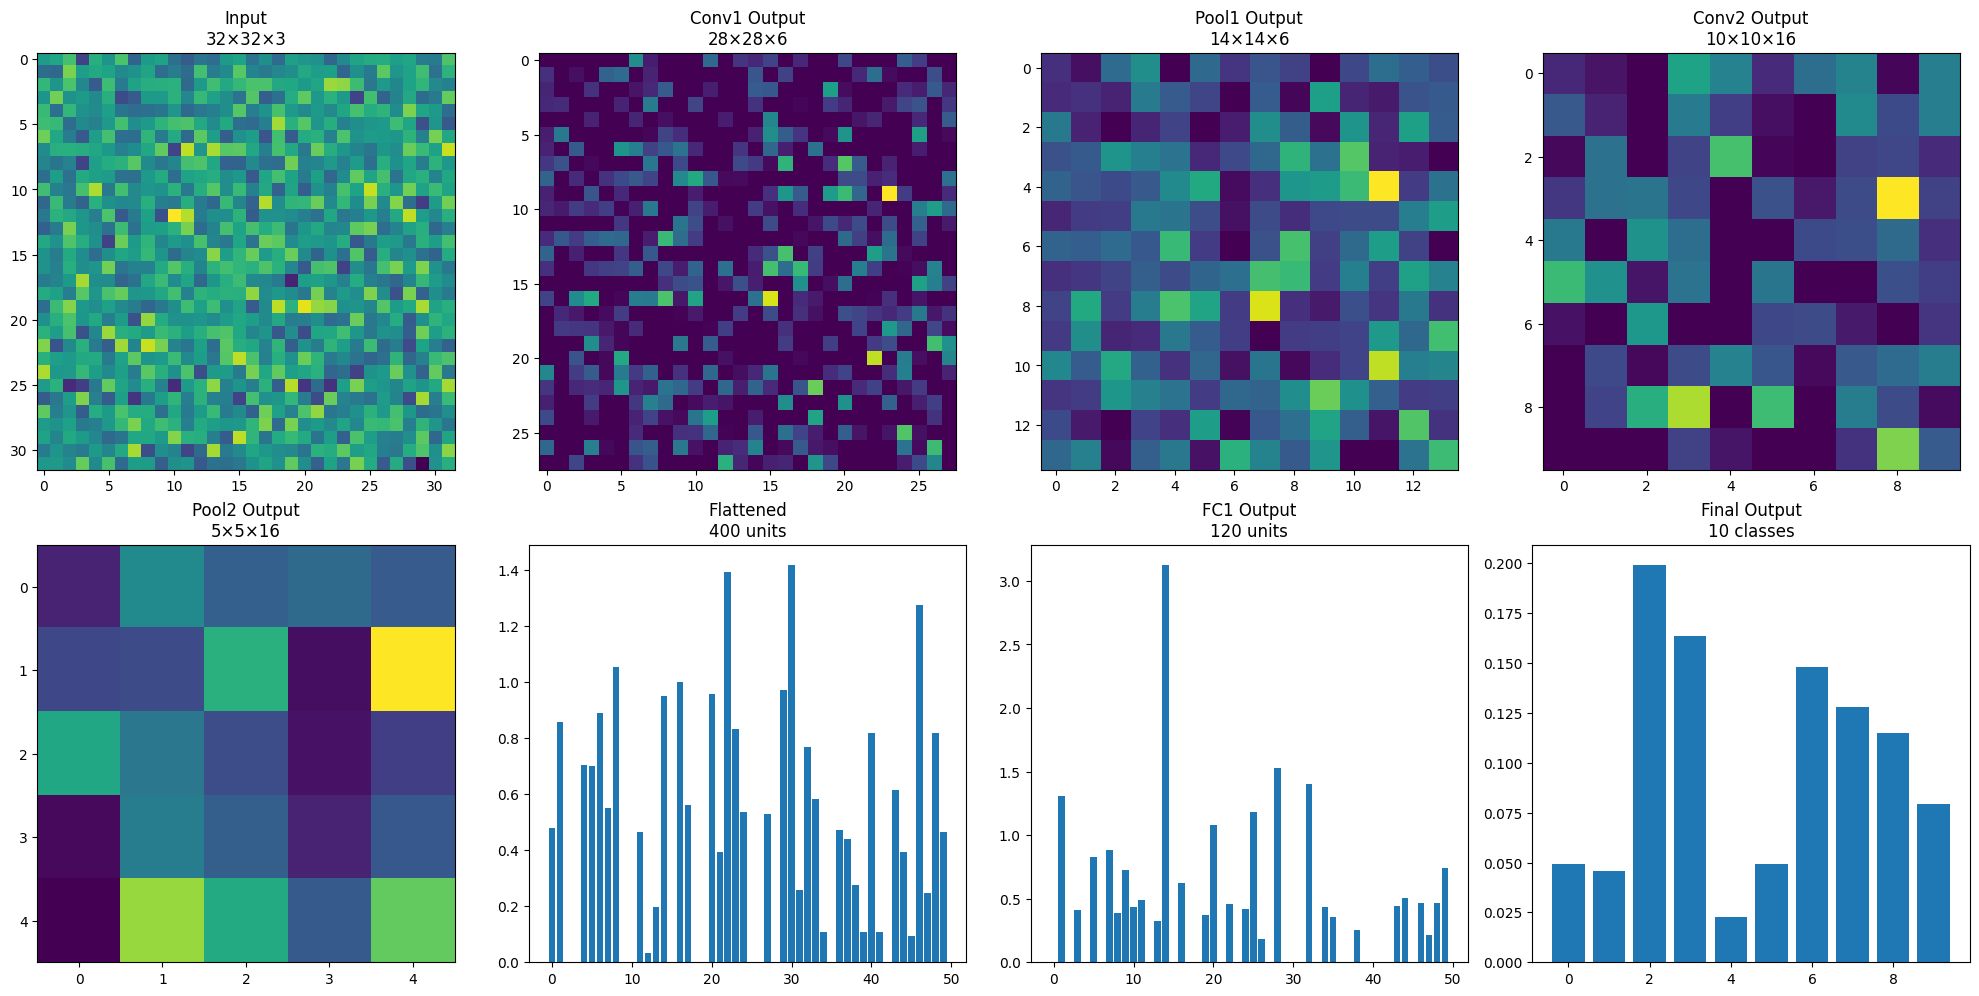

In [77]:

# Visualize architecture
def visualize_cnn_architecture():
    """Create a visual representation of the CNN architecture"""
    
    # Create sample data to trace through network
    sample_input = tf.random.normal((1, 32, 32, 3))
    
    # Get intermediate outputs
    layer_outputs = []
    x = sample_input
    
    for layer in lenet_model.layers:
        x = layer(x)
        layer_outputs.append(x)
    
    # Plot layer outputs
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Input
    axes[0, 0].imshow(sample_input[0, :, :, 0], cmap='viridis')
    axes[0, 0].set_title('Input\n32×32×3')
    
    # Conv1 output (show first channel)
    conv1_out = layer_outputs[0]
    axes[0, 1].imshow(conv1_out[0, :, :, 0], cmap='viridis')
    axes[0, 1].set_title(f'Conv1 Output\n{conv1_out.shape[1]}×{conv1_out.shape[2]}×{conv1_out.shape[3]}')
    
    # Pool1 output (show first channel)
    pool1_out = layer_outputs[1]
    axes[0, 2].imshow(pool1_out[0, :, :, 0], cmap='viridis')
    axes[0, 2].set_title(f'Pool1 Output\n{pool1_out.shape[1]}×{pool1_out.shape[2]}×{pool1_out.shape[3]}')
    
    # Conv2 output (show first channel)
    conv2_out = layer_outputs[2]
    axes[0, 3].imshow(conv2_out[0, :, :, 0], cmap='viridis')
    axes[0, 3].set_title(f'Conv2 Output\n{conv2_out.shape[1]}×{conv2_out.shape[2]}×{conv2_out.shape[3]}')
    
    # Pool2 output (show first channel)
    pool2_out = layer_outputs[3]
    axes[1, 0].imshow(pool2_out[0, :, :, 0], cmap='viridis')
    axes[1, 0].set_title(f'Pool2 Output\n{pool2_out.shape[1]}×{pool2_out.shape[2]}×{pool2_out.shape[3]}')
    
    # Flattened
    flatten_out = layer_outputs[4]
    axes[1, 1].bar(range(min(50, flatten_out.shape[1])), flatten_out[0, :50])
    axes[1, 1].set_title(f'Flattened\n{flatten_out.shape[1]} units')
    
    # FC1 output
    fc1_out = layer_outputs[5]
    axes[1, 2].bar(range(min(50, fc1_out.shape[1])), fc1_out[0, :50])
    axes[1, 2].set_title(f'FC1 Output\n{fc1_out.shape[1]} units')
    
    # Final output
    final_out = layer_outputs[-1]
    axes[1, 3].bar(range(final_out.shape[1]), final_out[0, :])
    axes[1, 3].set_title(f'Final Output\n{final_out.shape[1]} classes')
    
    plt.tight_layout()
    plt.show()

visualize_cnn_architecture()


### Cell 8: Pooling Layers Deep Dive
**Title:** Understanding Max Pooling and Average Pooling

**Description:**
Implements pooling operations manually to understand their purpose: dimensionality reduction, computational efficiency, and robustness improvement.

**Key Formulas:**
- Pooling output size: $\text{Output} = \left\lfloor \frac{n - f}{s} \right\rfloor + 1$
- Max pooling: $\text{output}[i,j] = \max(\text{window})$
- Average pooling: $\text{output}[i,j] = \frac{1}{f^2}\sum \text{window}$

**Pooling layers serve three main purposes:**
1. Reduce representation size (downsampling)
2. Speed up computation
3. Make feature detection more robust


**Learning Objectives:**
- Understand pooling purposes and benefits
- Compare max vs average pooling
- Learn pooling parameter selection

---


#### Implement max pooling manually to understand the process

In [78]:
def manual_max_pooling(input_matrix, pool_size=(2, 2), stride=2):
    """Implement max pooling manually to understand the process"""
    
    input_h, input_w = input_matrix.shape
    pool_h, pool_w = pool_size
    
    # Calculate output dimensions
    output_h = int((input_h - pool_h) / stride) + 1
    output_w = int((input_w - pool_w) / stride) + 1
    output = np.zeros((output_h, output_w))
    
    print(f"Max Pooling Operation:")
    print(f"Input shape: {input_matrix.shape}")
    print(f"Pool size: {pool_size}")
    print(f"Stride: {stride}")
    print(f"Output shape: {output.shape}")
    print(f"Size reduction: {(1 - (output_h * output_w)/(input_h * input_w))*100:.1f}%")
    
    # Apply max pooling
    for i in range(output_h):
        for j in range(output_w):
            # Calculate window boundaries
            start_i = i * stride
            end_i = start_i + pool_h
            start_j = j * stride
            end_j = start_j + pool_w
            
            # Extract pooling window
            window = input_matrix[start_i:end_i, start_j:end_j]
            
            # Apply max operation
            max_val = np.max(window)
            output[i, j] = max_val
            
            # Show first few operations
            if i < 2 and j < 2:
                print(f"\nWindow ({i},{j}): region [{start_i}:{end_i}, {start_j}:{end_j}]")
                print(f"Window values:\n{window}")
                print(f"Max value: {max_val}")
    
    return output

#### Implement average pooling manually

In [79]:
def manual_average_pooling(input_matrix, pool_size=(2, 2), stride=2):
    """Implement average pooling manually"""
    
    input_h, input_w = input_matrix.shape
    pool_h, pool_w = pool_size
    
    output_h = int((input_h - pool_h) / stride) + 1
    output_w = int((input_w - pool_w) / stride) + 1
    output = np.zeros((output_h, output_w))
    
    print(f"Average Pooling Operation:")
    print(f"Input shape: {input_matrix.shape}")
    print(f"Output shape: {output.shape}")
    
    for i in range(output_h):
        for j in range(output_w):
            start_i = i * stride
            end_i = start_i + pool_h
            start_j = j * stride
            end_j = start_j + pool_w
            
            window = input_matrix[start_i:end_i, start_j:end_j]
            avg_val = np.mean(window)
            output[i, j] = avg_val
            
            if i < 2 and j < 2:
                print(f"\nWindow ({i},{j}): {window.flatten()}")
                print(f"Average: {avg_val:.2f}")
    
    return output


Input Matrix (4×4):
[[1. 3. 2. 1.]
 [2. 9. 1. 3.]
 [5. 2. 6. 8.]
 [1. 3. 7. 4.]]

--- MAX POOLING ---
Max Pooling Operation:
Input shape: (4, 4)
Pool size: (2, 2)
Stride: 2
Output shape: (2, 2)
Size reduction: 75.0%

Window (0,0): region [0:2, 0:2]
Window values:
[[1. 3.]
 [2. 9.]]
Max value: 9.0

Window (0,1): region [0:2, 2:4]
Window values:
[[2. 1.]
 [1. 3.]]
Max value: 3.0

Window (1,0): region [2:4, 0:2]
Window values:
[[5. 2.]
 [1. 3.]]
Max value: 5.0

Window (1,1): region [2:4, 2:4]
Window values:
[[6. 8.]
 [7. 4.]]
Max value: 8.0

--- AVERAGE POOLING ---
Average Pooling Operation:
Input shape: (4, 4)
Output shape: (2, 2)

Window (0,0): [1. 3. 2. 9.]
Average: 3.75

Window (0,1): [2. 1. 1. 3.]
Average: 1.75

Window (1,0): [5. 2. 1. 3.]
Average: 2.75

Window (1,1): [6. 8. 7. 4.]
Average: 6.25


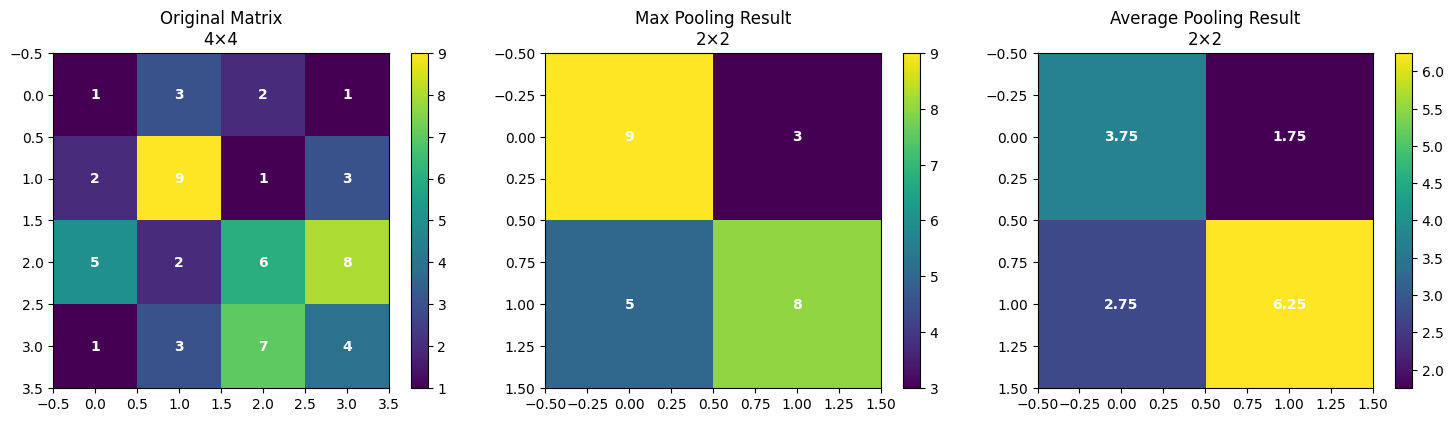


=== POOLING COMPARISON ===
Max Pooling Result:
[[9. 3.]
 [5. 8.]]
Average Pooling Result:
[[3.75 1.75]
 [2.75 6.25]]


In [82]:
# Create test matrix from the course notes
test_matrix = np.array([
    [1, 3, 2, 1],
    [2, 9, 1, 3],
    [5, 2, 6, 8],
    [1, 3, 7, 4]
], dtype=np.float32)

print("Input Matrix (4×4):")
print(test_matrix)

# Apply max pooling
print("\n--- MAX POOLING ---")
max_pooled = manual_max_pooling(test_matrix)

# Apply average pooling
print("\n--- AVERAGE POOLING ---")
avg_pooled = manual_average_pooling(test_matrix)

# Visualize pooling operations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original matrix
im1 = axes[0].imshow(test_matrix, cmap='viridis')
axes[0].set_title('Original Matrix\n4×4')
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{test_matrix[i,j]:.0f}', 
                    ha='center', va='center', color='white', fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# Max pooled result
im2 = axes[1].imshow(max_pooled, cmap='viridis')
axes[1].set_title('Max Pooling Result\n2×2')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{max_pooled[i,j]:.0f}', 
                    ha='center', va='center', color='white', fontweight='bold')
plt.colorbar(im2, ax=axes[1])

# Average pooled result
im3 = axes[2].imshow(avg_pooled, cmap='viridis')
axes[2].set_title('Average Pooling Result\n2×2')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{avg_pooled[i,j]:.2f}', 
                    ha='center', va='center', color='white', fontweight='bold')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# Compare pooling strategies
print(f"\n=== POOLING COMPARISON ===")
print(f"Max Pooling Result:\n{max_pooled}")
print(f"Average Pooling Result:\n{avg_pooled}")


### Cell 9: Why Convolutions? - Parameter Sharing Advantage
**Title:** Understanding the Revolutionary Efficiency of CNNs

**Description:**
Compares CNN parameter efficiency against fully connected networks. Demonstrates the massive parameter reduction achieved through parameter sharing.

**Key Formulas:**
- FC parameters: $n_{input} \times n_{output}$
- CNN parameters: $f \times f \times n_c \times n_{filters}$
- Parameter reduction: Often $10,000\times$ or more

**Three key advantages of CNNs over fully connected networks:**
1. Parameter sharing: Same filter used everywhere
2. Sparsity of connections: Local connectivity only  
3. Translation invariance: Position-independent detection

**Learning Objectives:**
- Understand parameter sharing benefits
- Compare CNN vs FC efficiency
- Learn why CNNs scale to large images

---


In [83]:
def compare_fc_vs_cnn_parameters():
    """Compare parameter counts between FC and CNN approaches"""
    
    print("=== PARAMETER SHARING ANALYSIS ===")
    
    # Example: 32×32×3 input, want 28×28×6 output
    input_size = 32 * 32 * 3  # 3,072 pixels
    output_size = 28 * 28 * 6  # 4,704 feature map values
    
    # Fully Connected approach
    fc_weights = input_size * output_size  # Every input connects to every output
    fc_biases = output_size
    fc_total = fc_weights + fc_biases
    
    # CNN approach (5×5 filters, 6 filters)
    filter_size = 5 * 5 * 3  # 75 weights per filter (including all channels)
    cnn_weights = filter_size * 6  # 6 filters
    cnn_biases = 6  # One bias per filter
    cnn_total = cnn_weights + cnn_biases
    
    print(f"Input: 32×32×3 = {input_size:,} pixels")
    print(f"Desired output: 28×28×6 = {output_size:,} values")
    print()
    
    print("FULLY CONNECTED APPROACH:")
    print(f"  Weights: {input_size:,} × {output_size:,} = {fc_weights:,}")
    print(f"  Biases: {fc_biases:,}")
    print(f"  Total parameters: {fc_total:,}")
    print(f"  Memory (float32): {fc_total * 4 / (1024**2):.1f} MB")
    print()
    
    print("CNN APPROACH:")
    print(f"  Weights per filter: 5×5×3 = {filter_size}")
    print(f"  Total weights: {filter_size} × 6 = {cnn_weights}")
    print(f"  Biases: {cnn_biases}")
    print(f"  Total parameters: {cnn_total}")
    print(f"  Memory (float32): {cnn_total * 4 / 1024:.1f} KB")
    print()
    
    reduction_factor = fc_total / cnn_total
    print(f"PARAMETER REDUCTION: {reduction_factor:,.0f}× fewer parameters!")
    print(f"Memory reduction: {fc_total * 4 / (cnn_total * 4):.0f}× less memory!")
    
    return fc_total, cnn_total, reduction_factor


# Demonstrate parameter sharing
fc_params, cnn_params, reduction = compare_fc_vs_cnn_parameters()

=== PARAMETER SHARING ANALYSIS ===
Input: 32×32×3 = 3,072 pixels
Desired output: 28×28×6 = 4,704 values

FULLY CONNECTED APPROACH:
  Weights: 3,072 × 4,704 = 14,450,688
  Biases: 4,704
  Total parameters: 14,455,392
  Memory (float32): 55.1 MB

CNN APPROACH:
  Weights per filter: 5×5×3 = 75
  Total weights: 75 × 6 = 450
  Biases: 6
  Total parameters: 456
  Memory (float32): 1.8 KB

PARAMETER REDUCTION: 31,700× fewer parameters!
Memory reduction: 31700× less memory!



=== PARAMETER SHARING DEMONSTRATION ===
Shared Filter (used everywhere):
[[ 1.  0. -1.]
 [ 1.  0. -1.]
 [ 1.  0. -1.]]
Filter parameters: 9 weights

Input Image:
[[2. 0. 5. 6. 4. 5.]
 [2. 1. 2. 0. 1. 9.]
 [5. 2. 1. 5. 9. 7.]
 [0. 2. 6. 8. 5. 7.]
 [2. 1. 8. 0. 9. 9.]
 [8. 0. 3. 7. 1. 6.]]


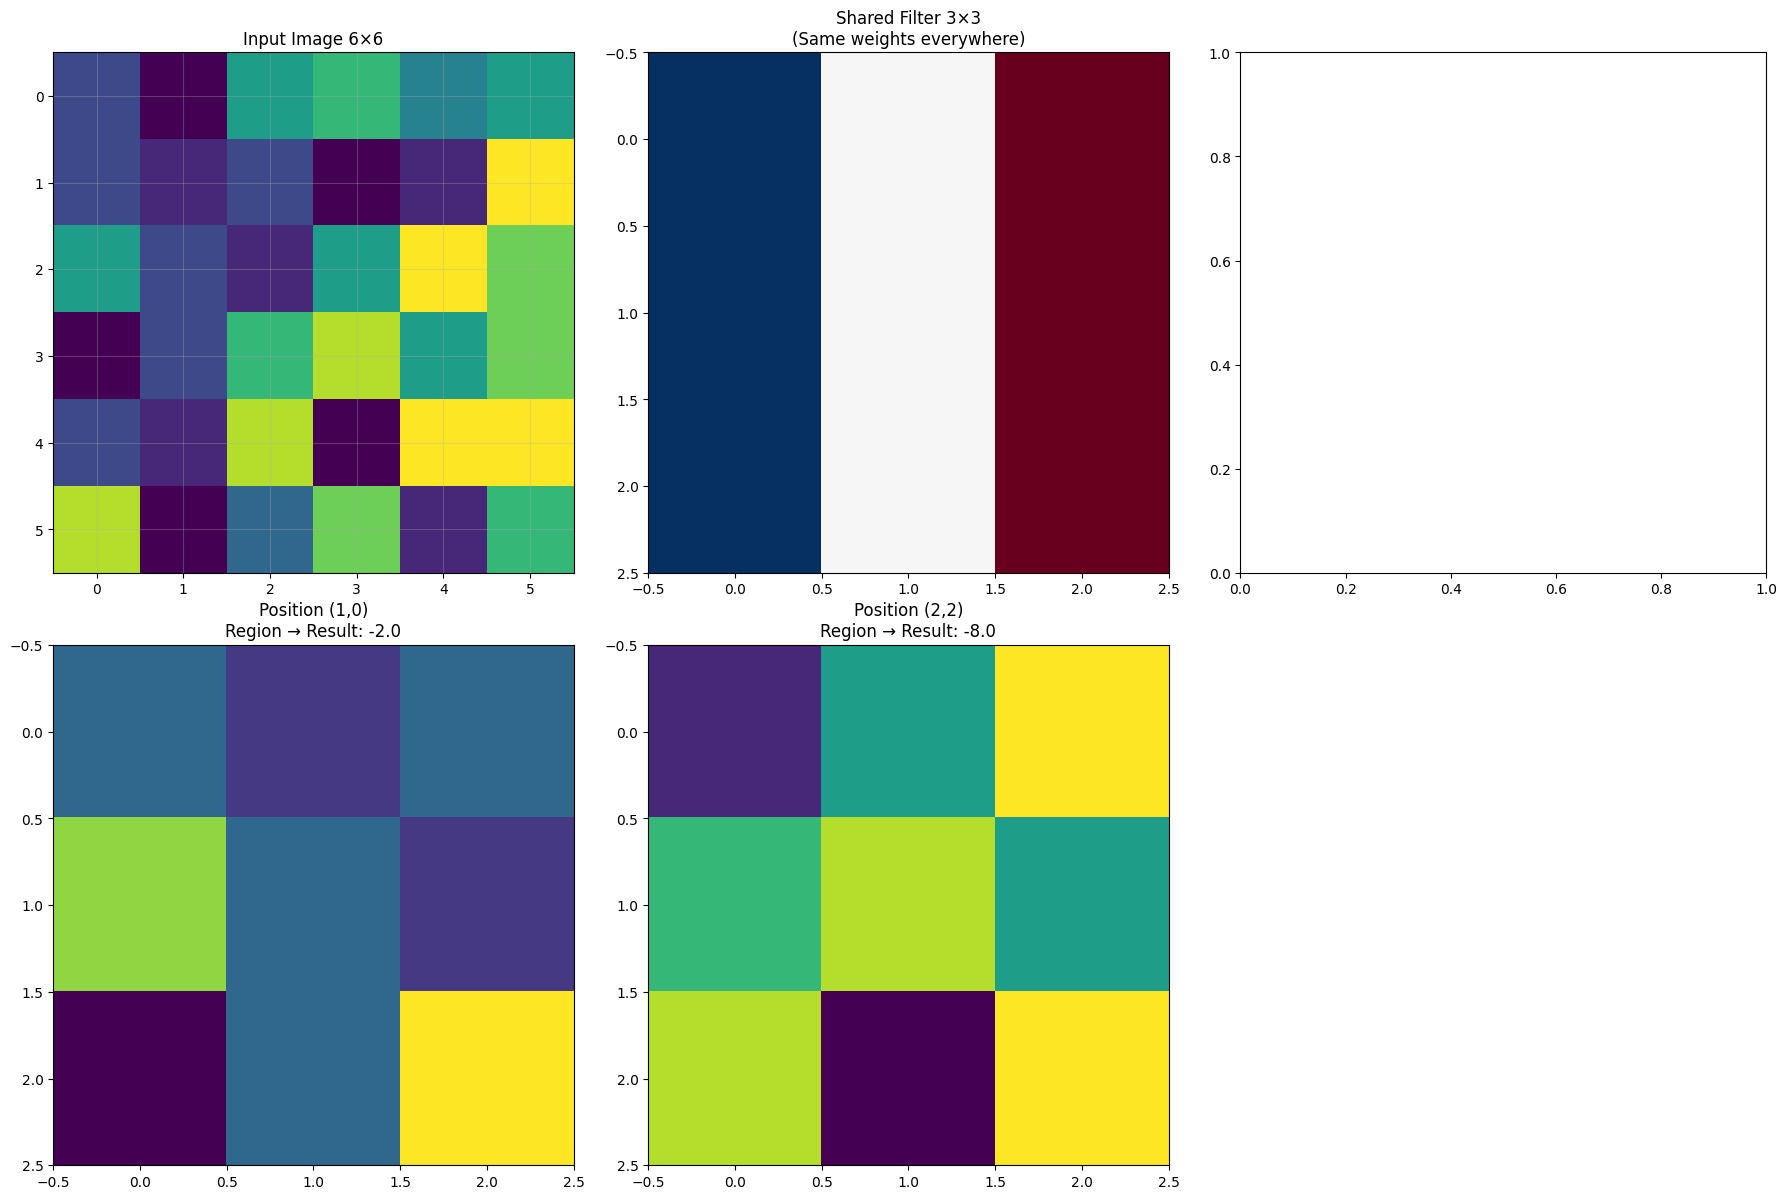


Key insight: Same 9 parameters used at all 16 positions!
Without sharing: Would need 144 = 144 parameters
With sharing: Only need 9 parameters
Sharing benefit: 16× parameter reduction


In [84]:
# Visualize parameter sharing concept
def demonstrate_parameter_sharing():
    """Visualize how parameter sharing works in CNNs"""
    
    print(f"\n=== PARAMETER SHARING DEMONSTRATION ===")
    
    # Create a simple 5×5 filter
    shared_filter = np.array([
        [1, 0, -1],
        [1, 0, -1], 
        [1, 0, -1]
    ], dtype=np.float32)
    
    # Create 6×6 input
    input_img = np.random.randint(0, 10, (6, 6)).astype(np.float32)
    
    print("Shared Filter (used everywhere):")
    print(shared_filter)
    print(f"Filter parameters: {shared_filter.size} weights")
    
    print(f"\nInput Image:")
    print(input_img)
    
    # Show how same filter is applied at different positions
    positions = [(0, 0), (0, 1), (1, 0), (2, 2)]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Show input and filter
    axes[0, 0].imshow(input_img, cmap='viridis')
    axes[0, 0].set_title('Input Image 6×6')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].imshow(shared_filter, cmap='RdBu')
    axes[0, 1].set_title('Shared Filter 3×3\n(Same weights everywhere)')
    
    # Show filter applications at different positions
    for idx, (i, j) in enumerate(positions[:4]):
        if idx < 4:
            row = idx // 2
            col = (idx % 2) + 1 if row == 0 else idx % 2
            
            # Extract region
            region = input_img[i:i+3, j:j+3]
            result = np.sum(region * shared_filter)
            
            # Highlight region on input
            highlighted = input_img.copy()
            highlighted[i:i+3, j:j+3] += 2  # Highlight the region
            
            if row == 1:
                axes[row, col].imshow(region, cmap='viridis')
                axes[row, col].set_title(f'Position ({i},{j})\nRegion → Result: {result:.1f}')
            elif idx == 2:
                # Show convolution result
                full_result = manual_convolution(input_img, shared_filter)
                axes[0, 2].imshow(full_result, cmap='RdBu')
                axes[0, 2].set_title('Full Convolution Result\nSame filter applied everywhere')
    
    # Hide unused subplots
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nKey insight: Same {shared_filter.size} parameters used at all {4*4} positions!")
    print(f"Without sharing: Would need {shared_filter.size * 4 * 4} = {shared_filter.size * 16} parameters")
    print(f"With sharing: Only need {shared_filter.size} parameters")
    print(f"Sharing benefit: {16}× parameter reduction")

demonstrate_parameter_sharing()

Let’s carefully untangle the **parameter sharing** idea in CNNs.


#### What “parameter sharing” actually means

* In a convolution layer, **one filter (kernel)** has a fixed set of weights (and usually one bias).
* That same filter is **slid across the entire input image**, producing one feature map.
* Because the filter weights are **shared across all spatial positions**, we don’t learn separate weights for each pixel/patch.

This is what makes CNNs efficient compared to a fully connected layer, where every pixel has its own separate weight.


#### Filters and parameters per layer

Each **filter** has its own set of weights.
If you have **multiple filters**, each filter learns its own unique weights (they are **not shared between filters**, only within the same filter across spatial positions).

So:

* **Layer 1 with 3 filters** → 3 separate weight sets.
* **Layer 2 with 4 filters** → 4 separate weight sets.
* In total, 7 different filters, each with its own parameters.

#### Example calculation

Let’s assume:

* Input image has **3 channels (RGB)**
* Filter size = **3×3**

##### First Conv Layer (3 filters):

* Each filter weight shape = (3 channels × 3 × 3) = 27 weights
* +1 bias per filter
* Per filter = 27 + 1 = 28 parameters
* For 3 filters = 3 × 28 = **84 parameters**

##### Second Conv Layer (4 filters, input = output of layer 1)

* Input depth = **3** (since first conv produced 3 feature maps)
* Each filter weight shape = (3 channels × 3 × 3) = 27
* +1 bias
* Per filter = 27 + 1 = 28
* For 4 filters = 4 × 28 = **112 parameters**

#### Total so far

* Layer 1 → 84 params
* Layer 2 → 112 params
* **Total = 196 parameters**

So the idea is:

* **Yes, each filter has its own weights.**
* The "sharing" happens only across spatial positions of the image, not between different filters or layers.

### Cell 10: Translation Invariance Demonstration
**Title:** Understanding Position-Independent Feature Detection

**Description:**
Shows how CNNs detect features regardless of their position in the image through parameter sharing and consistent filter application.

**Key Formulas:**
- Translation equivariance: $f(\text{shift}(x)) = \text{shift}(f(x))$
- Same filter response at all positions
- Pooling adds local translation invariance

Translation invariance means the same features are detected regardless of position.

**This is achieved through:**
1. Parameter sharing (same filter everywhere)
2. Pooling operations (local position independence)

**Learning Objectives:**
- Understand translation invariance
- See position-independent detection
- Learn robustness benefits

---



=== TRANSLATION INVARIANCE ===
Vertical line detector (normalized):
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Input shape: (8, 8)
Kernel shape: (3, 3)
Output shape: (6, 6)
Output size formula: (8 - 3 + 1) × (8 - 3 + 1) = 6 × 6

Position (0, 0):
Region:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 5. 5.]]
Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Element-wise product sum: 1.111111119389534

Position (0, 1):
Region:
[[0. 0. 0.]
 [0. 0. 0.]
 [5. 5. 0.]]
Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Element-wise product sum: 1.111111119389534

Position (1, 0):
Region:
[[0. 0. 0.]
 [0. 5. 5.]
 [0. 5. 5.]]
Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Element-wise product sum: 2.222222238779068

Position (1, 1):
Region:
[[0. 0.

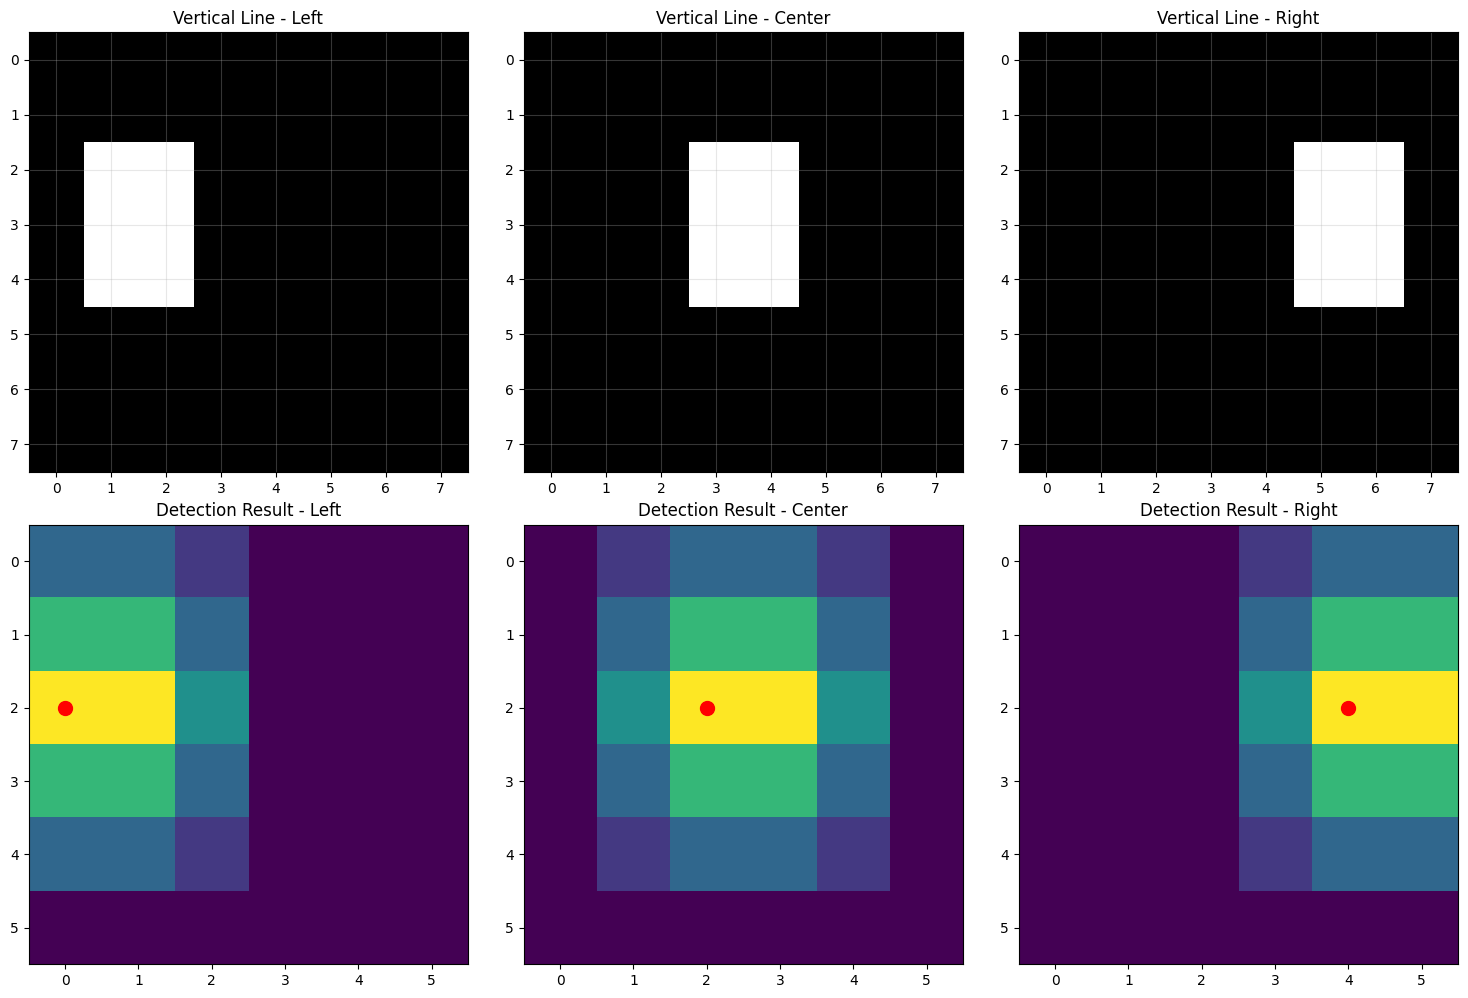


Key insight: Same detector finds vertical lines everywhere!
Response strength should be similar regardless of position.


In [86]:
def demonstrate_translation_invariance():
    """Show how CNNs detect features regardless of position"""
    
    print(f"\n=== TRANSLATION INVARIANCE ===")
    
    # Create images with same feature at different positions
    def create_pattern_at_position(size, pattern_pos):
        img = np.zeros((size, size))
        # Add a thicker vertical line (2 pixels wide)
        x, y = pattern_pos
        if x+1 < size and y+2 < size:
            img[y:y+3, x:x+2] = 5  # Thicker vertical line
        return img
    
    # Create 3 images with vertical line at different positions
    img1 = create_pattern_at_position(8, (1, 2))  # Left
    img2 = create_pattern_at_position(8, (3, 2))  # Center  
    img3 = create_pattern_at_position(8, (5, 2))  # Right
    
    images = [img1, img2, img3]
    positions = ['Left', 'Center', 'Right']
    
    # Line detector (detects bright regions, not edges)
    detector = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.float32) / 9.0  # Normalize to get average
    
    print("Vertical line detector (normalized):")
    print(detector)
    
    # Apply detector to each image
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for i, (img, pos) in enumerate(zip(images, positions)):
        # Original image
        axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=5)
        axes[0, i].set_title(f'Vertical Line - {pos}')
        axes[0, i].grid(True, alpha=0.3)
        
        # Apply detector
        detected = manual_convolution(img, detector)
        
        axes[1, i].imshow(detected, cmap='viridis')
        axes[1, i].set_title(f'Detection Result - {pos}')
        
        # Find maximum response
        max_response = np.max(detected)
        max_pos = np.unravel_index(np.argmax(detected), detected.shape)
        
        print(f"\n{pos} position:")
        print(f"  Max response: {max_response:.2f}")
        print(f"  Response position: {max_pos}")
        
        # Mark maximum on result
        axes[1, i].plot(max_pos[1], max_pos[0], 'ro', markersize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nKey insight: Same detector finds vertical lines everywhere!")
    print(f"Response strength should be similar regardless of position.")


demonstrate_translation_invariance()

### Cell 11: Building and Training a Complete CNN
**Title:** Practical Implementation with Real Data

**Description:**
Implements and trains a complete CNN on CIFAR-10 dataset. Shows data preprocessing, model compilation, training, and evaluation with real performance metrics.

**Key Formulas:**
- CIFAR-10 input: $32 \times 32 \times 3$
- Cross-entropy loss: $L = -\sum_{i} y_i \log(\hat{y}_i)$
- Adam optimizer with adaptive learning rates

**Learning Objectives:**
- Train CNNs on real datasets
- Understand practical implementation
- Learn model evaluation techniques

---


In [89]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 131s 1us/step


##### Class names for CIFAR-10

In [90]:
# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training data: {x_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test data: {x_test.shape}")
print(f"Test labels: {y_test.shape}")

Training data: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test data: (10000, 32, 32, 3)
Test labels: (10000, 1)


##### Normalize pixel values

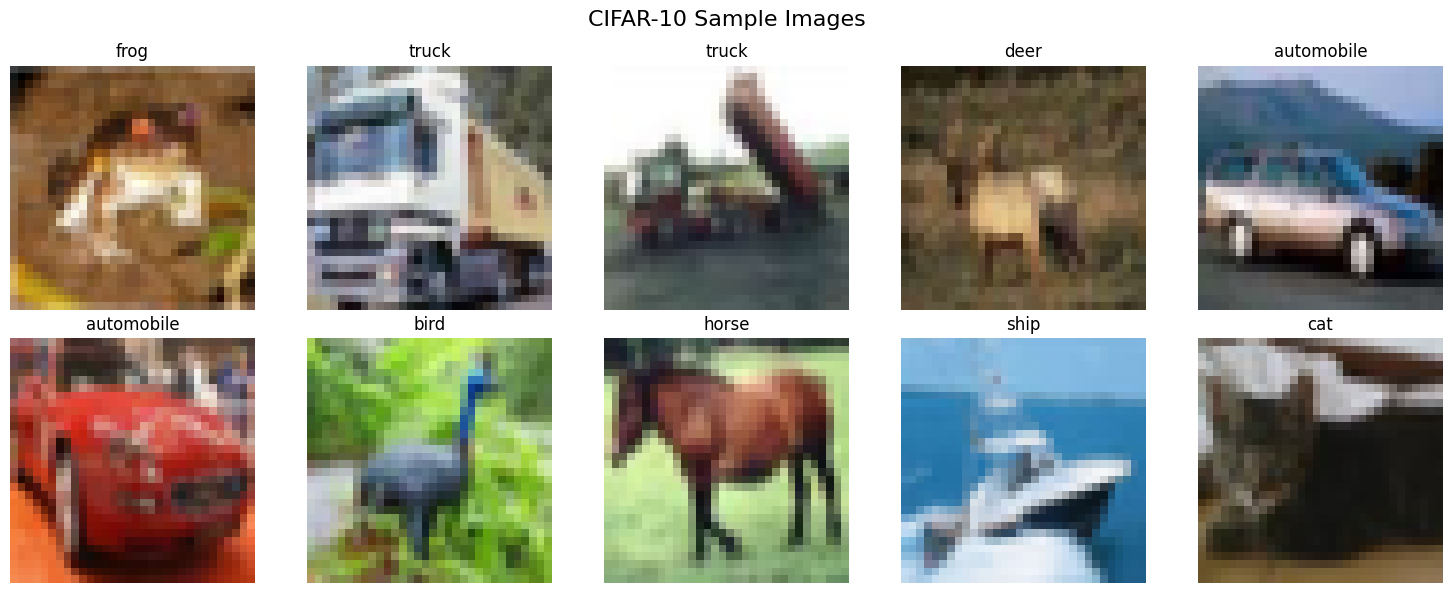

In [91]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical
y_train_categorical = keras.utils.to_categorical(y_train, 10)
y_test_categorical = keras.utils.to_categorical(y_test, 10)

# Visualize some examples
def visualize_cifar10_samples():
    """Show sample images from CIFAR-10"""
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    for i in range(10):
        row = i // 5
        col = i % 5
        
        axes[row, col].imshow(x_train[i])
        axes[row, col].set_title(f'{class_names[y_train[i][0]]}')
        axes[row, col].axis('off')
    
    plt.suptitle('CIFAR-10 Sample Images', fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_cifar10_samples()


In [92]:
# Create an improved CNN model
def create_improved_cnn():
    """Create a CNN with modern techniques"""
    
    model = keras.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        
        # Classification head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    
    return model


In [93]:
# Create and compile model
improved_model = create_improved_cnn()

print(f"\n=== IMPROVED CNN ARCHITECTURE ===")
improved_model.summary()


=== IMPROVED CNN ARCHITECTURE ===


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737,834 (2.81 MB)

 Trainable params: 736,362 (2.81 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [94]:
# Compile model
improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Calculate parameter comparison
def compare_model_complexities():
    """Compare our models with fully connected equivalent"""
    
    # Our CNN
    cnn_params = improved_model.count_params()
    
    # Equivalent fully connected (theoretical)
    input_size = 32 * 32 * 3  # 3,072
    fc_params_theoretical = input_size * 512 + 512 * 10  # First layer + output layer
    
    print(f"\n=== MODEL COMPLEXITY COMPARISON ===")
    print(f"Our CNN: {cnn_params:,} parameters")
    print(f"Equivalent FC (simplified): {fc_params_theoretical:,} parameters") 
    print(f"Real FC would be much larger due to intermediate layers!")
    print(f"CNN efficiency gain: {fc_params_theoretical/cnn_params:.1f}× more efficient")

compare_model_complexities()



=== MODEL COMPLEXITY COMPARISON ===
Our CNN: 737,834 parameters
Equivalent FC (simplified): 1,577,984 parameters
Real FC would be much larger due to intermediate layers!
CNN efficiency gain: 2.1× more efficient


In [95]:
# Train for a few epochs (demonstration)
print(f"\n=== TRAINING DEMONSTRATION ===")
print("Training for 2 epochs as demonstration...")

# Use subset for faster training in demo
train_subset = 5000
test_subset = 1000

history = improved_model.fit(
    x_train[:train_subset], y_train_categorical[:train_subset],
    batch_size=32,
    epochs=2,
    validation_data=(x_test[:test_subset], y_test_categorical[:test_subset]),
    verbose=1
)

# Evaluate model
test_loss, test_accuracy = improved_model.evaluate(
    x_test[:test_subset], y_test_categorical[:test_subset], verbose=0
)

print(f"\nTest accuracy after 2 epochs: {test_accuracy:.4f}")
print(f"This demonstrates that CNNs can learn meaningful patterns quickly!")


=== TRAINING DEMONSTRATION ===
Training for 2 epochs as demonstration...
Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.2392 - loss: 2.7541 - val_accuracy: 0.0900 - val_loss: 3.6525
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3318 - loss: 2.0629 - val_accuracy: 0.1470 - val_loss: 2.9379

Test accuracy after 2 epochs: 0.1470
This demonstrates that CNNs can learn meaningful patterns quickly!



First layer learned filters shape: (3, 3, 3, 32)
These are the edge detectors the model learned automatically!


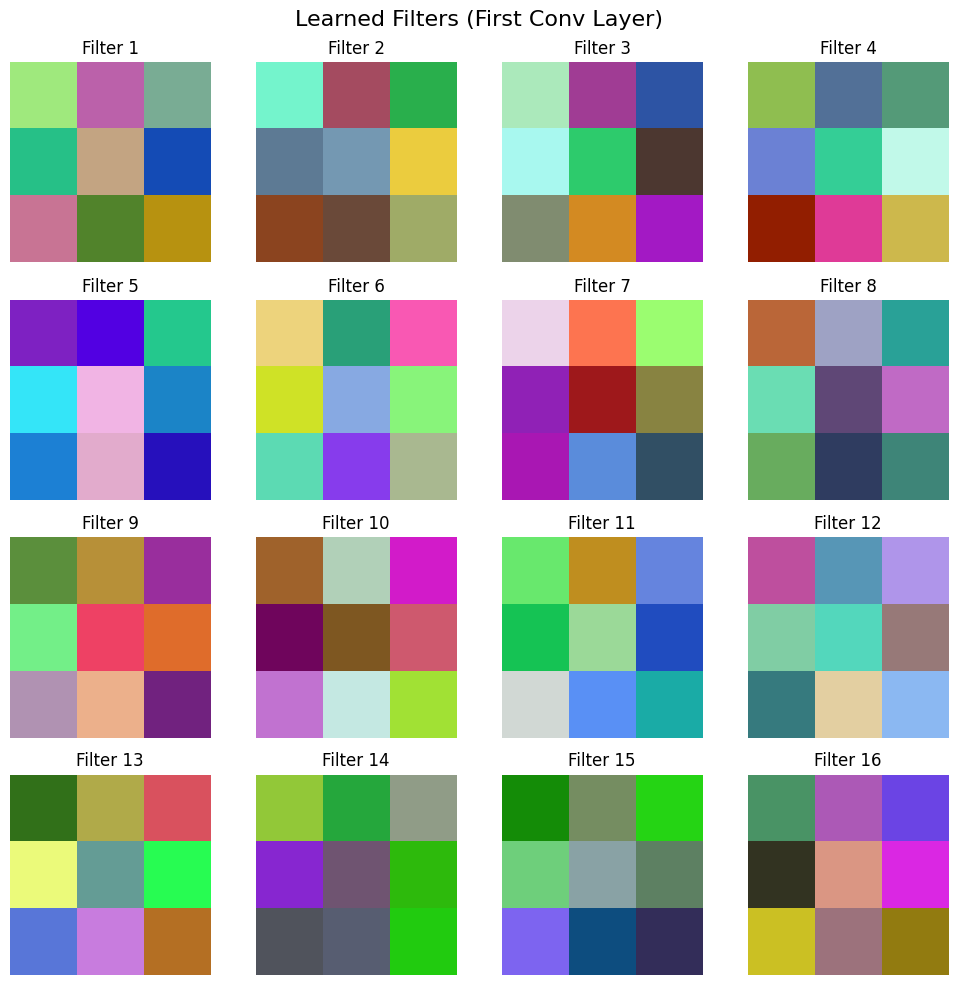

In [96]:
# Visualize what the model learned
def visualize_learned_features():
    """Visualize filters learned by the first convolutional layer"""
    
    # Get weights from first conv layer
    conv_layer = improved_model.layers[0]
    filters, biases = conv_layer.get_weights()
    
    print(f"\nFirst layer learned filters shape: {filters.shape}")
    print(f"These are the edge detectors the model learned automatically!")
    
    # Normalize filters for visualization
    f_min, f_max = filters.min(), filters.max()
    filters_norm = (filters - f_min) / (f_max - f_min)
    
    # Plot first 16 filters
    n_filters = min(16, filters.shape[3])
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    
    for i in range(n_filters):
        row = i // 4
        col = i % 4
        
        # Get filter and convert to displayable format
        filt = filters_norm[:, :, :, i]
        
        axes[row, col].imshow(filt)
        axes[row, col].set_title(f'Filter {i+1}')
        axes[row, col].axis('off')
    
    plt.suptitle('Learned Filters (First Conv Layer)', fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_learned_features()